# Notebook de entrenamiento de modelos

El objetivo de este notebook es entrenar y comparar distintos modelos de clasificación supervisada para la detección temprana de sepsis a partir del dataset preprocesado. Se evalúan múltiples algoritmos, se selecciona el mejor modelo, se ajusta el umbral de decisión y se analizan los errores e interpretabilidad del modelo final.

## Instalar e importar librerías

In [1]:
!pip install xgboost lightgbm shap imbalanced-learn -q

In [2]:
import json
import warnings
import time
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Configuración general

Realizamos algunas configuraciones y definimos algunos parámetros que se utilizarán a lo largo de notebook.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR    = Path("/content/drive/MyDrive/data/processed")
OUTPUT_DIR  = Path("/content/drive/MyDrive/reports")
MODELS_DIR  = Path("/content/drive/MyDrive/models")

TRAIN_PATH = DATA_DIR / "train_preprocessed.parquet"
TEST_PATH = DATA_DIR / "test_preprocessed.parquet"

TRAIN_PATH_SCALED = DATA_DIR / "train_preprocessed_scaled.parquet"
TEST_PATH_SCALED = DATA_DIR / "test_preprocessed_scaled.parquet"

for d in [OUTPUT_DIR, MODELS_DIR, OUTPUT_DIR / "figures", OUTPUT_DIR / "metrics"]:
    d.mkdir(parents=True, exist_ok=True)

# --- Reproducibilidad ---
RANDOM_STATE = 42
N_FOLDS      = 5
N_ITER_SEARCH = 10   # iteraciones para RandomizedSearchCV

# --- Columnas no predictoras ---
TARGET_COL = "SepsisLabel"
AUX_COLS   = ["PatientID", "Hospital", "TimeStep"]

# --- Estilo de figuras ---
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "DejaVu Sans",
})
PALETTE = ["#2176AE", "#F79824", "#57B8FF", "#B66D0D", "#22577A", "#80B918"]

print("Configuración lista.")




Mounted at /content/drive
Configuración lista.


## Carga de datos

In [4]:
# Dataset base, sin escalar: modelos basados en árboles
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

# Dataset escalado: regresión logística
df_train_scaled = pd.read_parquet(TRAIN_PATH_SCALED)
df_test_scaled = pd.read_parquet(TEST_PATH_SCALED)

print(f"Train: {df_train.shape}")
print(f"Test:  {df_test.shape}")


Train: (1240596, 61)
Test:  (311614, 61)


## Comprobaciones básicas

Realizamos algunas comprobaciones para validar que el conjunto de datos se ha preprocesado correctamente.

In [5]:
# Columnas
print("Columnas en train no presentes en test:", set(df_train.columns) - set(df_test.columns))
print("Columnas en test no presentes en train:", set(df_test.columns) - set(df_train.columns))

# Nulos
train_nulls = df_train.isna().sum().sum()
test_nulls  = df_test.isna().sum().sum()
print(f"\nNulos train: {train_nulls} | Nulos test: {test_nulls}")

Columnas en train no presentes en test: set()
Columnas en test no presentes en train: set()

Nulos train: 0 | Nulos test: 0


In [6]:
# Distribución de SepsisLabel
sepsis_train = df_train.groupby("PatientID")[TARGET_COL].max()
sepsis_test  = df_test.groupby("PatientID")[TARGET_COL].max()

print("--- Distribución de SepsisLabel (nivel paciente) ---")
print(f"Train  — pacientes totales: {len(sepsis_train):,}")
print(f"         con sepsis:        {sepsis_train.sum():,} ({sepsis_train.mean()*100:.2f}%)")
print(f"Test   — pacientes totales: {len(sepsis_test):,}")
print(f"         con sepsis:        {sepsis_test.sum():,} ({sepsis_test.mean()*100:.2f}%)")

# Distribución a nivel de fila
row_pos_train = df_train[TARGET_COL].mean() * 100
row_pos_test  = df_test[TARGET_COL].mean() * 100
print(f"\nDesbalance a nivel fila — train: {row_pos_train:.2f}% positivos | test: {row_pos_test:.2f}% positivos")

--- Distribución de SepsisLabel (nivel paciente) ---
Train  — pacientes totales: 32,268
         con sepsis:        2,346 (7.27%)
Test   — pacientes totales: 8,068
         con sepsis:        586 (7.26%)

Desbalance a nivel fila — train: 1.80% positivos | test: 1.78% positivos


## Separación de variables

Separamos las variables auxiliares y la variable objetivo de las variables predictoras que se utilizarán en los modelos.

In [8]:
feature_cols = [col for col in df_train.columns if col not in AUX_COLS + [TARGET_COL]]


X_train = df_train[feature_cols].reset_index(drop=True)
y_train = df_train[TARGET_COL].reset_index(drop=True)
groups  = df_train["PatientID"].reset_index(drop=True)  # para GroupKFold

X_test  = df_test[feature_cols].reset_index(drop=True)
y_test  = df_test[TARGET_COL].reset_index(drop=True)

print(f"X_train: {X_train.shape} | y_train positivos: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}  | y_test positivos:  {y_test.mean()*100:.2f}%")

X_train: (1240596, 57) | y_train positivos: 1.80%
X_test:  (311614, 57)  | y_test positivos:  1.78%


In [9]:
feature_cols_scaled = [
    col for col in df_train_scaled.columns
    if col not in AUX_COLS + [TARGET_COL]
]

X_train_lr = df_train_scaled[feature_cols_scaled].reset_index(drop=True)
y_train_lr = df_train_scaled[TARGET_COL].reset_index(drop=True)

X_test_lr = df_test_scaled[feature_cols_scaled].reset_index(drop=True)
y_test_lr = df_test_scaled[TARGET_COL].reset_index(drop=True)
groups_lr = df_train_scaled["PatientID"].reset_index(drop=True)

## Funciones auxiliares

## Definición de métricas

Dado el fuerte **desbalance de clases** y el **contexto clínico**, las métricas prioritarias que consideramos son:


*   **AUPRC** (área bajo la curva de Precision-Recall): métrica principal para datos desbalanceados
*   **AUROC** (área bajo la curva Receiver Operating Characteristic): capacidad discriminativa global
*   **Recall** (sensibilidad): coste de los falsos negativos
*   **F1-score**: equilibrio entre precision y recall
*   **Specificity**: evitar falsas alarmas excesivas

Se incluye también la exactitud (accuracy) por completitud pero no es una métrica fiable con datos tan desbalanceados.








In [10]:
def compute_metrics_patient(
    df_ref: pd.DataFrame,
    y_prob: np.ndarray,
    threshold: float = 0.5,
) -> dict:
    """Agrega predicciones por paciente (max prob) y calcula métricas a ese nivel.

    Args:
        df_ref: DataFrame con columnas PatientID y SepsisLabel (nivel fila).
        y_prob: Probabilidades predichas alineadas con df_ref.
        threshold: Umbral de decisión.
    """
    df_eval = df_ref[["PatientID", TARGET_COL]].copy()
    df_eval["y_prob"] = y_prob

    df_patient = df_eval.groupby("PatientID").agg(
        y_true=(TARGET_COL, "max"),   # paciente positivo si tiene al menos 1 fila positiva
        y_prob=("y_prob", "max"),     # probabilidad máxima predicha en cualquier timestep
    ).reset_index()

    y_true = df_patient["y_true"].values
    y_prob_agg = df_patient["y_prob"].values
    y_pred = (y_prob_agg >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy":    round((tp + tn) / (tp + tn + fp + fn), 4),
        "Precision":   round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":      round(recall_score(y_true, y_pred, zero_division=0), 4),
        "Specificity": round(specificity, 4),
        "F1":          round(f1_score(y_true, y_pred, zero_division=0), 4),
        "AUROC":       round(roc_auc_score(y_true, y_prob_agg), 4),
        "AUPRC":       round(average_precision_score(y_true, y_prob_agg), 4),
        "n_patients":  len(df_patient),
        "n_positivos": int(y_true.sum()),
    }


def compute_metrics_row(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = 0.5,
) -> dict:
    """Calcula métricas a nivel de fila/registro horario.

    Args:
        y_true: Etiquetas reales a nivel fila.
        y_prob: Probabilidades predichas alineadas con y_true.
        threshold: Umbral de decisión para convertir probabilidades en clase binaria.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0

    # AUROC solo se puede calcular si hay ambas clases presentes
    auroc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    auprc = average_precision_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan

    return {
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "Specificity": round(specificity, 4),
        "F1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "AUROC": round(auroc, 4),
        "AUPRC": round(auprc, 4),
        "n_rows": len(y_true),
        "n_positivos": int(y_true.sum()),
    }

def cv_score(pipeline, X: pd.DataFrame, y: pd.Series, groups: pd.Series, scoring: str = "average_precision") -> float:
    """Evalúa un pipeline con GroupKFold y devuelve la media del scoring indicado."""
    from sklearn.model_selection import cross_val_score
    gkf = GroupKFold(n_splits=N_FOLDS)
    scores = cross_val_score(pipeline, X, y, cv=gkf, groups=groups, scoring=scoring, n_jobs=-1)
    return scores.mean()




print("Funciones de métricas definidas.")

Funciones de métricas definidas.


In [11]:
def find_best_threshold_row(
    y_true,
    y_prob,
    metric="F1",
    thresholds=None,
):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    results = []

    for threshold in thresholds:
        metrics = compute_metrics_row(
            y_true=y_true,
            y_prob=y_prob,
            threshold=threshold
        )

        results.append({
            "threshold": threshold,
            **metrics
        })

    df_thresholds = pd.DataFrame(results)

    best_idx = df_thresholds[metric].idxmax()
    best_threshold = df_thresholds.loc[best_idx, "threshold"]

    return best_threshold, df_thresholds

In [12]:
def save_model_artifacts(
    model_name: str,
    model,
    threshold: float,
    metrics_row: dict,
    metrics_patient: dict,
    params: dict | None = None,
) -> None:
    """Guarda modelo entrenado, umbral, métricas y parámetros."""

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )

    model_path = MODELS_DIR / f"{safe_name}.joblib"
    metadata_path = MODELS_DIR / f"{safe_name}_metadata.json"

    joblib.dump(model, model_path)

    metadata = {
        "model_name": model_name,
        "threshold": float(threshold),
        "metrics_row": metrics_row,
        "metrics_patient": metrics_patient,
        "params": params if params is not None else {},
    }

    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4, ensure_ascii=False)

    print(f"Modelo guardado en: {model_path}")
    print(f"Metadatos guardados en: {metadata_path}")

## Diccionarios de resultados

In [13]:
all_results_row: dict[str, dict] = {}
all_results_patient: dict[str, dict] = {}
training_times: dict[str, float] = {}
thresholds: dict[str, float] = {}
probabilities_test: dict[str, np.ndarray] = {}
models: dict[str, object] = {}

## Modelo baseline — DummyClassifier

Establece el umbral mínimo que cualquier modelo real debe superar. Se usa la estrategia stratified para respetar el desbalance de clases.

In [14]:

dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

# Métricas principales: nivel fila / registro horario
metrics_dummy_row = compute_metrics_row(
    y_true=y_test,
    y_prob=y_prob_dummy,
    threshold=0.5
)

# Métricas complementarias: nivel paciente
metrics_dummy_patient = compute_metrics_patient(
    df_ref=df_test,
    y_prob=y_prob_dummy,
    threshold=0.5
)

# Guardar en diccionarios los resultados
models["Baseline (Dummy)"] = dummy
probabilities_test["Baseline (Dummy)"] = y_prob_dummy
thresholds["Baseline (Dummy)"] = THRESHOLD
all_results_row["Baseline (Dummy)"] = metrics_dummy_row
all_results_patient["Baseline (Dummy)"] = metrics_dummy_patient

print("Métricas baseline a nivel fila/test:")
for k, v in metrics_dummy_row.items():
    print(f"  {k}: {v}")

print("\nMétricas baseline a nivel paciente/test:")
for k, v in metrics_dummy_patient.items():
    print(f"  {k}: {v}")

Métricas baseline a nivel fila/test:
  Accuracy: 0.9646
  Precision: 0.0151
  Recall: 0.0153
  Specificity: 0.9818
  F1: 0.0152
  AUROC: 0.4986
  AUPRC: 0.0178
  n_rows: 311614
  n_positivos: 5553

Métricas baseline a nivel paciente/test:
  Accuracy: 0.5238
  Precision: 0.0758
  Recall: 0.4966
  Specificity: 0.5259
  F1: 0.1316
  AUROC: 0.5113
  AUPRC: 0.0742
  n_patients: 8068
  n_positivos: 586


La alta puntuación en accuracy del modelo baseline es engañosa; responde únicamente a que el algoritmo reproduce de forma estratificada la distribución original de pacientes con y sin sepsis del conjunto de entrenamiento, sin llegar a optimizar la clasificación.

## Submuestra para búsqueda de hiperparámetros
Por motivos de coste computacional, la búsqueda de hiperparámetros se realizará sobre una submuestra común del conjunto de entrenamiento.

In [15]:
# Submuestra común para búsqueda de hiperparámetros
patient_labels = (
    df_train[["PatientID", TARGET_COL]]
    .groupby("PatientID")[TARGET_COL]
    .max()
    .reset_index()
)

pos_patients = patient_labels[patient_labels[TARGET_COL] == 1]
neg_patients = patient_labels[patient_labels[TARGET_COL] == 0]

sample_pos = pos_patients
sample_neg = neg_patients.sample(
    n=min(len(neg_patients), len(pos_patients) * 4),
    random_state=RANDOM_STATE
)

selected_patients_search = pd.concat([sample_pos, sample_neg])["PatientID"]


# Dataset sin escalar

df_train_search = df_train[
    df_train["PatientID"].isin(selected_patients_search)
].copy()

X_search = df_train_search[feature_cols].reset_index(drop=True)
y_search = df_train_search[TARGET_COL].reset_index(drop=True)
groups_search = df_train_search["PatientID"].reset_index(drop=True)


# Dataset escalado para regresión logística

df_train_search_scaled = df_train_scaled[
    df_train_scaled["PatientID"].isin(selected_patients_search)
].copy()

X_search_lr = df_train_search_scaled[feature_cols_scaled].reset_index(drop=True)
y_search_lr = df_train_search_scaled[TARGET_COL].reset_index(drop=True)
groups_search_lr = df_train_search_scaled["PatientID"].reset_index(drop=True)



print(f"X_search: {X_search.shape}")
print(f"Pacientes búsqueda: {groups_search.nunique()}")
print(f"Positivos a nivel fila: {y_search.mean()*100:.2f}%")
print(f"Pacientes positivos: {patient_labels[patient_labels['PatientID'].isin(selected_patients_search)][TARGET_COL].sum()}")

X_search: (483515, 57)
Pacientes búsqueda: 11730
Positivos a nivel fila: 4.63%
Pacientes positivos: 2346


## Regresión Logística
Modelo lineal interpretable. Requiere que el conjunto de datos esté escalado.

Se usa `class_weight='balanced'` para compensar el desbalance. Sirve también como referencia de modelo simple.

Utilizamos `RandomizedSearchCV` para hacer un ajuste de hiperparámetros con validación cruzada. Este ajuste de hiperparámetros se realiza sobre un submuestreo de pacientes pues el volumen de datos de nuestro conjunto es muy alto.

In [16]:

start_time = time.time()

lr_pipeline = Pipeline([
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        tol=1e-3,
        random_state=RANDOM_STATE,
        solver="saga",
        n_jobs=1,
        verbose=2
    ))
])

lr_param_dist = {
    "clf__C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2"],
}

gkf = GroupKFold(n_splits=N_FOLDS)

lr_search = RandomizedSearchCV(
    lr_pipeline,
    lr_param_dist,
    n_iter=N_ITER_SEARCH,  # cubre todo el espacio (6 C × 2 penalties)
    scoring="average_precision",
    cv=gkf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)
lr_search.fit(X_search_lr, y_search_lr, groups=groups_search_lr)

search_time  = time.time() - start_time
training_times["Logistic Regression Search"] = search_time
print(f"Ajuste de hiperparámetros: {search_time:.2f} segundos")

print(f"Mejores parámetros LR: {lr_search.best_params_}")
print(f"Mejor AUPRC CV:        {lr_search.best_score_:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
convergence after 33 epochs took 28 seconds
Ajuste de hiperparámetros: 702.27 segundos
Mejores parámetros LR: {'clf__penalty': 'l1', 'clf__C': 0.01}
Mejor AUPRC CV:        0.1167


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   27.9s finished


Mostramos los resultados para el modelo usando los mejores hiperparámetros.

In [17]:
start_time_retrain = time.time()

# Reentrenamiento con todos los datos de train
best_lr = lr_search.best_estimator_
best_lr.fit(X_train_lr, y_train_lr)

retrain_time = time.time() - start_time_retrain
print(f"Reentrenamiento: {retrain_time:.2f} segundos")

# Predicciones out-of-fold sobre train para ajustar el umbral
y_prob_lr_oof = cross_val_predict(
    best_lr,
    X_train_lr,
    y_train_lr,
    cv=GroupKFold(n_splits=N_FOLDS),
    groups=groups_lr,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Ajuste del umbral usando predicciones OOF a nivel fila
best_threshold_lr, threshold_scores_lr = find_best_threshold_row(
    y_true=y_train_lr,
    y_prob=y_prob_lr_oof,
    metric="F1"
)

print(f"Mejor umbral Regresión Logística: {best_threshold_lr:.3f}")

# Predicciones probabilísticas sobre test
y_prob_lr = best_lr.predict_proba(X_test_lr)[:, 1]

# Predicciones binarias en test usando el umbral ajustado con OOF
y_pred_lr = (y_prob_lr >= best_threshold_lr).astype(int)

# Métricas principales: nivel fila / registro horario
metrics_lr_row = compute_metrics_row(
    y_true=y_test_lr,
    y_prob=y_prob_lr,
    threshold=best_threshold_lr
)

# Métricas complementarias: nivel paciente
metrics_lr_patient = compute_metrics_patient(
    df_ref=df_test_scaled,
    y_prob=y_prob_lr,
    threshold=best_threshold_lr
)
# Guardar los resultados
models["Logistic Regression"] = best_lr
probabilities_test["Logistic Regression"] = y_prob_lr
thresholds["Logistic Regression"] = best_threshold_lr
all_results_row["Logistic Regression"] = metrics_lr_row
all_results_patient["Logistic Regression"] = metrics_lr_patient
training_times["Logistic Regression Retrain"] = retrain_time
save_model_artifacts(
    model_name="Logistic Regression",
    model=best_lr,
    threshold=best_threshold_lr,
    metrics_row=metrics_lr_row,
    metrics_patient=metrics_lr_patient,
    params=lr_search.best_params_
)

print("Métricas Regresión Logística a nivel fila/test:")
for k, v in metrics_lr_row.items():
    print(f"  {k}: {v}")

print("\nMétricas Regresión Logística a nivel paciente/test:")
for k, v in metrics_lr_patient.items():
    print(f"  {k}: {v}")

convergence after 74 epochs took 165 seconds
Reentrenamiento: 165.63 segundos


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.8min finished


Mejor umbral Regresión Logística: 0.780
Modelo guardado en: /content/drive/MyDrive/models/logistic_regression.joblib
Metadatos guardados en: /content/drive/MyDrive/models/logistic_regression_metadata.json
Métricas Regresión Logística a nivel fila/test:
  Accuracy: 0.9483
  Precision: 0.107
  Recall: 0.2586
  Specificity: 0.9608
  F1: 0.1514
  AUROC: 0.7544
  AUPRC: 0.077
  n_rows: 311614
  n_positivos: 5553

Métricas Regresión Logística a nivel paciente/test:
  Accuracy: 0.8794
  Precision: 0.3047
  Recall: 0.5154
  Specificity: 0.9079
  F1: 0.383
  AUROC: 0.8017
  AUPRC: 0.3556
  n_patients: 8068
  n_positivos: 586


## Random Forest
Ensemble de árboles de decisión. No requiere escalado.

Se controla el desbalance con `class_weight='balanced_subsample'`.

Los hiperparámetros se ajustan de forma análoga al modelo anterior.

In [18]:
start_time_search = time.time()

rf_pipeline = Pipeline([
    ("clf", RandomForestClassifier(
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=2
    )),
])

rf_param_dist = {
    "clf__n_estimators":      [50, 100, 200],
    "clf__max_depth":         [8, 10, 20],
    "clf__min_samples_split": [2, 10, 20],
    "clf__min_samples_leaf":  [1, 4, 10],
    "clf__max_features":      ["sqrt"],
}

gkf = GroupKFold(n_splits=N_FOLDS)

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=N_ITER_SEARCH,
    scoring="average_precision",
    cv=gkf,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=2,
)

rf_search.fit(X_search, y_search, groups=groups_search)

search_time = time.time() - start_time_search
training_times["Random Forest Search"] = search_time

print(f"Ajuste de hiperparámetros: {search_time:.2f} segundos")
print(f"Mejores parámetros RF:     {rf_search.best_params_}")
print(f"Mejor AUPRC CV:            {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tre

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:   36.2s


building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.5min finished


Mostramos los resultados para el modelo usando los mejores hiperparámetros.

In [19]:
start_time_retrain = time.time()

# Reentrenamiento con todos los datos y más árboles
best_params_rf = rf_search.best_params_.copy()

best_rf = Pipeline([
    ("clf", RandomForestClassifier(
        **{k.replace("clf__", ""): v for k, v in best_params_rf.items()},
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=2,
    )),
])

best_rf.fit(X_train, y_train)

retrain_time = time.time() - start_time_retrain
print(f"Reentrenamiento: {retrain_time:.2f} segundos")

# Ajuste de umbral con predicciones out-of-fold sobre train
from sklearn.model_selection import cross_val_predict

y_prob_rf_oof = cross_val_predict(
    best_rf, X_train, y_train,
    cv=GroupKFold(n_splits=N_FOLDS),
    groups=groups,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

# Ajuste del umbral usando predicciones out-of-fold sobre train a nivel fila
best_threshold_rf, threshold_scores_rf = find_best_threshold_row(
    y_true=y_train,
    y_prob=y_prob_rf_oof,
    metric="F1"
)

print(f"Mejor umbral Random Forest: {best_threshold_rf:.3f}")

# Predicciones sobre test
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Predicciones binarias en test usando el umbral ajustado con OOF
y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

# Métricas principales: nivel fila / registro horario
metrics_rf_row = compute_metrics_row(
    y_true=y_test,
    y_prob=y_prob_rf,
    threshold=best_threshold_rf
)

# Métricas complementarias: nivel paciente
metrics_rf_patient = compute_metrics_patient(
    df_ref=df_test,
    y_prob=y_prob_rf,
    threshold=best_threshold_rf
)

all_results_row["Random Forest"] = metrics_rf_row
all_results_patient["Random Forest"] = metrics_rf_patient
models["Random Forest"] = best_rf
probabilities_test["Random Forest"] = y_prob_rf
thresholds["Random Forest"] = best_threshold_rf
training_times["Random Forest Retrain"] = retrain_time
save_model_artifacts(
    model_name="Random Forest",
    model=best_rf,
    threshold=best_threshold_rf,
    metrics_row=metrics_rf_row,
    metrics_patient=metrics_rf_patient,
    params=best_params_rf,
)

print("\nMétricas Random Forest a nivel fila/test:")
for k, v in metrics_rf_row.items():
    print(f"  {k}: {v}")

print("\nMétricas Random Forest a nivel paciente/test:")
for k, v in metrics_rf_patient.items():
    print(f"  {k}: {v}")

Reentrenamiento: 142.26 segundos
Mejor umbral Random Forest: 0.670
Modelo guardado en: /content/drive/MyDrive/models/random_forest.joblib
Metadatos guardados en: /content/drive/MyDrive/models/random_forest_metadata.json

Métricas Random Forest a nivel fila/test:
  Accuracy: 0.9466
  Precision: 0.1189
  Recall: 0.3112
  Specificity: 0.9582
  F1: 0.1721
  AUROC: 0.8056
  AUPRC: 0.0952
  n_rows: 311614
  n_positivos: 5553

Métricas Random Forest a nivel paciente/test:
  Accuracy: 0.9208
  Precision: 0.4523
  Recall: 0.4283
  Specificity: 0.9594
  F1: 0.44
  AUROC: 0.8295
  AUPRC: 0.4654
  n_patients: 8068
  n_positivos: 586


## XGBoost
Gradient boosting optimizado. No requiere escalado.

El desbalance se controla con `scale_pos_weight = n_negativos / n_positivos`.

Los hiperparámetros se ajustan de forma análoga al modelo anterior.

In [20]:
start_time_search = time.time()

# scale_pos_weight calculado sobre la submuestra común de búsqueda
scale_pos_weight_search = (y_search == 0).sum() / (y_search == 1).sum()
print(f"scale_pos_weight búsqueda: {scale_pos_weight_search:.2f}")

xgb_pipeline = Pipeline([
    ("clf", xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight_search,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbosity=0,
        tree_method="hist",
    )),
])

xgb_param_dist = {
    "clf__n_estimators":     [100, 200, 300],
    "clf__max_depth":        [3, 4, 5],
    "clf__learning_rate":    [0.03, 0.05, 0.07, 0.1],
    "clf__subsample":        [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
    "clf__reg_alpha":        [0, 0.1, 0.5],
    "clf__reg_lambda":       [5, 10, 15],
}

gkf = GroupKFold(n_splits=N_FOLDS)

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=N_ITER_SEARCH,
    scoring="average_precision",
    cv=gkf,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=2,
)

xgb_search.fit(X_search, y_search, groups=groups_search)

search_time = time.time() - start_time_search
training_times["XGBoost Search"] = search_time

print(f"Ajuste de hiperparámetros: {search_time:.2f} segundos")
print(f"Mejores parámetros XGB:    {xgb_search.best_params_}")
print(f"Mejor AUPRC CV:            {xgb_search.best_score_:.4f}")

scale_pos_weight búsqueda: 20.62
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Ajuste de hiperparámetros: 211.48 segundos
Mejores parámetros XGB:    {'clf__subsample': 0.8, 'clf__reg_lambda': 15, 'clf__reg_alpha': 0, 'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}
Mejor AUPRC CV:            0.1393


Mostramos los resultados para el modelo usando los mejores hiperparámetros.

In [21]:
start_time_retrain = time.time()

best_params_xgb = xgb_search.best_params_.copy()

scale_pos_weight_train = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight train completo: {scale_pos_weight_train:.2f}")

best_xgb = Pipeline([
    ("clf", xgb.XGBClassifier(
        **{k.replace("clf__", ""): v for k, v in best_params_xgb.items()},
        scale_pos_weight=scale_pos_weight_train,
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbosity=0,
        tree_method="hist",
    )),
])

best_xgb.fit(X_train, y_train)

retrain_time = time.time() - start_time_retrain


print(f"Reentrenamiento: {retrain_time:.2f} segundos")

# Ajuste de umbral con predicciones out-of-fold sobre train
y_prob_xgb_oof = cross_val_predict(
    best_xgb,
    X_train,
    y_train,
    cv=GroupKFold(n_splits=N_FOLDS),
    groups=groups,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

best_threshold_xgb, threshold_scores_xgb = find_best_threshold_row(
    y_true=y_train,
    y_prob=y_prob_xgb_oof,
    metric="F1"
)

print(f"Mejor umbral XGBoost: {best_threshold_xgb:.3f}")

# Predicciones probabilísticas sobre test
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Predicciones binarias en test usando el umbral ajustado con OOF
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

metrics_xgb_row = compute_metrics_row(
    y_true=y_test,
    y_prob=y_prob_xgb,
    threshold=best_threshold_xgb
)

metrics_xgb_patient = compute_metrics_patient(
    df_ref=df_test,
    y_prob=y_prob_xgb,
    threshold=best_threshold_xgb
)

all_results_row["XGBoost"] = metrics_xgb_row
all_results_patient["XGBoost"] = metrics_xgb_patient
models["XGBoost"] = best_xgb
probabilities_test["XGBoost"] = y_prob_xgb
thresholds["XGBoost"] = best_threshold_xgb
training_times["XGBoost Retrain"] = retrain_time
save_model_artifacts(
    model_name="XGBoost",
    model=best_xgb,
    threshold=best_threshold_xgb,
    metrics_row=metrics_xgb_row,
    metrics_patient=metrics_xgb_patient,
    params=best_params_xgb,
)

print("\nMétricas XGBoost a nivel fila/test:")
for k, v in metrics_xgb_row.items():
    print(f"  {k}: {v}")

print("\nMétricas XGBoost a nivel paciente/test:")
for k, v in metrics_xgb_patient.items():
    print(f"  {k}: {v}")



scale_pos_weight train completo: 54.48
Reentrenamiento: 32.66 segundos
Mejor umbral XGBoost: 0.790
Modelo guardado en: /content/drive/MyDrive/models/xgboost.joblib
Metadatos guardados en: /content/drive/MyDrive/models/xgboost_metadata.json

Métricas XGBoost a nivel fila/test:
  Accuracy: 0.9475
  Precision: 0.1242
  Recall: 0.3222
  Specificity: 0.9588
  F1: 0.1793
  AUROC: 0.8233
  AUPRC: 0.0999
  n_rows: 311614
  n_positivos: 5553

Métricas XGBoost a nivel paciente/test:
  Accuracy: 0.906
  Precision: 0.3895
  Recall: 0.5171
  Specificity: 0.9365
  F1: 0.4443
  AUROC: 0.8464
  AUPRC: 0.4898
  n_patients: 8068
  n_positivos: 586


## LightGBM
Alternativa a XGBoost con entrenamiento más rápido y menor uso de memoria. Especialmente útil en un dataset grande como el que tenemos.

Se usa `is_unbalance=True` para el desbalance.

Los hiperparámetros se ajustan de forma análoga al modelo anterior.

In [22]:

start_time_search = time.time()

lgbm_pipeline = Pipeline([
    ("clf", lgb.LGBMClassifier(
        is_unbalance=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )),
])

lgbm_param_dist = {
    "clf__n_estimators":     [100, 200, 300],
    "clf__max_depth":        [-1, 5, 10],
    "clf__learning_rate":    [0.03, 0.05, 0.1],
    "clf__num_leaves":       [31, 63, 127],
    "clf__subsample":        [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
    "clf__reg_alpha":        [0, 0.1, 0.5],
    "clf__reg_lambda":       [1, 5, 10],
}

gkf = GroupKFold(n_splits=N_FOLDS)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=N_ITER_SEARCH,
    scoring="average_precision",
    cv=gkf,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
)

lgbm_search.fit(
    X_search,
    y_search,
    groups=groups_search,
)

search_time = time.time() - start_time_search
training_times["LightGBM Search"] = search_time

print(f"Ajuste de hiperparámetros LightGBM: {search_time:.2f} segundos")
print(f"Mejores parámetros LGBM:           {lgbm_search.best_params_}")
print(f"Mejor AUPRC CV:                    {lgbm_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=200, clf__num_leaves=63, clf__reg_alpha=0.5, clf__reg_lambda=5, clf__subsample=1.0; total time=   8.1s
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=200, clf__num_leaves=63, clf__reg_alpha=0.5, clf__reg_lambda=5, clf__subsample=1.0; total time=  10.0s
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=200, clf__num_leaves=63, clf__reg_alpha=0.5, clf__reg_lambda=5, clf__subsample=1.0; total time=   6.7s
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=200, clf__num_leaves=63, clf__reg_alpha=0.5, clf__reg_lambda=5, clf__subsample=1.0; total time=   9.7s
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.05, clf__max_depth=-1, clf__n_estimators=200, clf__num_leaves=63, clf__reg_alp

In [23]:
start_time_retrain = time.time()

best_params_lgbm = lgbm_search.best_params_.copy()

best_lgbm = Pipeline([
    ("clf", lgb.LGBMClassifier(
        **{k.replace("clf__", ""): v for k, v in best_params_lgbm.items()},
        is_unbalance=True,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=-1,
    )),
])

best_lgbm.fit(X_train, y_train)

retrain_time = time.time() - start_time_retrain


print(f"Reentrenamiento: {retrain_time:.2f} segundos")

# Ajuste de umbral con predicciones out-of-fold sobre train
y_prob_lgbm_oof = cross_val_predict(
    best_lgbm,
    X_train,
    y_train,
    cv=GroupKFold(n_splits=N_FOLDS),
    groups=groups,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

best_threshold_lgbm, threshold_scores_lgbm = find_best_threshold_row(
    y_true=y_train,
    y_prob=y_prob_lgbm_oof,
    metric="F1"
)

print(f"Mejor umbral LightGBM: {best_threshold_lgbm:.3f}")

# Predicciones probabilísticas sobre test
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = (y_prob_lgbm >= best_threshold_lgbm).astype(int)

metrics_lgbm_row = compute_metrics_row(
    y_true=y_test,
    y_prob=y_prob_lgbm,
    threshold=best_threshold_lgbm
)

metrics_lgbm_patient = compute_metrics_patient(
    df_ref=df_test,
    y_prob=y_prob_lgbm,
    threshold=best_threshold_lgbm
)

all_results_row["LightGBM"] = metrics_lgbm_row
all_results_patient["LightGBM"] = metrics_lgbm_patient
models["LightGBM"] = best_lgbm
probabilities_test["LightGBM"] = y_prob_lgbm
thresholds["LightGBM"] = best_threshold_lgbm
training_times["LightGBM Retrain"] = retrain_time
save_model_artifacts(
    model_name="LightGBM",
    model=best_lgbm,
    threshold=best_threshold_lgbm,
    metrics_row=metrics_lgbm_row,
    metrics_patient=metrics_lgbm_patient,
    params=best_params_lgbm,
)

print("\nMétricas LightGBM a nivel fila/test:")
for k, v in metrics_lgbm_row.items():
    print(f"  {k}: {v}")

print("\nMétricas LightGBM a nivel paciente/test:")
for k, v in metrics_lgbm_patient.items():
    print(f"  {k}: {v}")

Reentrenamiento: 33.37 segundos
Mejor umbral LightGBM: 0.800
Modelo guardado en: /content/drive/MyDrive/models/lightgbm.joblib
Metadatos guardados en: /content/drive/MyDrive/models/lightgbm_metadata.json

Métricas LightGBM a nivel fila/test:
  Accuracy: 0.9502
  Precision: 0.1287
  Recall: 0.3108
  Specificity: 0.9618
  F1: 0.182
  AUROC: 0.8217
  AUPRC: 0.1033
  n_rows: 311614
  n_positivos: 5553

Métricas LightGBM a nivel paciente/test:
  Accuracy: 0.9168
  Precision: 0.4343
  Recall: 0.4795
  Specificity: 0.9511
  F1: 0.4558
  AUROC: 0.8477
  AUPRC: 0.5068
  n_patients: 8068
  n_positivos: 586


## Tabla comparativa de métricas
Comparación de todos los modelos evaluados en el conjunto de test. Las métricas están ordenadas por AUPRC, pues es la métrica que se considera principal.

In [24]:
metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1", "AUROC", "AUPRC"]

metric_format = {
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1": "{:.4f}",
    "AUROC": "{:.4f}",
    "AUPRC": "{:.4f}",
    "n_rows": "{:.0f}",
    "n_positivos": "{:.0f}",
    "n_patients": "{:.0f}",
}

# Tabla principal: métricas a nivel fila / registro horario
df_results_row = pd.DataFrame(all_results_row).T
df_results_row = df_results_row.sort_values("AUPRC", ascending=False)

display(
    df_results_row.style
    .format(metric_format)
    .highlight_max(subset=metric_cols, axis=0, color="#d4edda")
    .highlight_min(subset=metric_cols, axis=0, color="#f8d7da")
    .set_caption("Comparativa de modelos — test a nivel fila")
)

# Tabla complementaria: métricas a nivel paciente
df_results_patient = pd.DataFrame(all_results_patient).T
df_results_patient = df_results_patient.sort_values("AUPRC", ascending=False)

display(
    df_results_patient.style
    .format(metric_format)
    .highlight_max(subset=metric_cols, axis=0, color="#d4edda")
    .highlight_min(subset=metric_cols, axis=0, color="#f8d7da")
    .set_caption("Comparativa de modelos — test a nivel paciente")
)

# Guardar resultados
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)

df_results_row.to_csv(OUTPUT_DIR / "metrics" / "model_comparison_row.csv")
df_results_patient.to_csv(OUTPUT_DIR / "metrics" / "model_comparison_patient.csv")

print("Tablas guardadas.")

,Accuracy,Precision,Recall,Specificity,F1,AUROC,AUPRC,n_rows,n_positivos
LightGBM,0.9502,0.1287,0.3108,0.9618,0.1820,0.8217,0.1033,311614,5553
XGBoost,0.9475,0.1242,0.3222,0.9588,0.1793,0.8233,0.0999,311614,5553
Random Forest,0.9466,0.1189,0.3112,0.9582,0.1721,0.8056,0.0952,311614,5553
Logistic Regression,0.9483,0.1070,0.2586,0.9608,0.1514,0.7544,0.0770,311614,5553
Baseline (Dummy),0.9646,0.0151,0.0153,0.9818,0.0152,0.4986,0.0178,311614,5553


,Accuracy,Precision,Recall,Specificity,F1,AUROC,AUPRC,n_patients,n_positivos
LightGBM,0.9168,0.4343,0.4795,0.9511,0.4558,0.8477,0.5068,8068,586
XGBoost,0.9060,0.3895,0.5171,0.9365,0.4443,0.8464,0.4898,8068,586
Random Forest,0.9208,0.4523,0.4283,0.9594,0.4400,0.8295,0.4654,8068,586
Logistic Regression,0.8794,0.3047,0.5154,0.9079,0.3830,0.8017,0.3556,8068,586
Baseline (Dummy),0.5238,0.0758,0.4966,0.5259,0.1316,0.5113,0.0742,8068,586


Tablas guardadas.


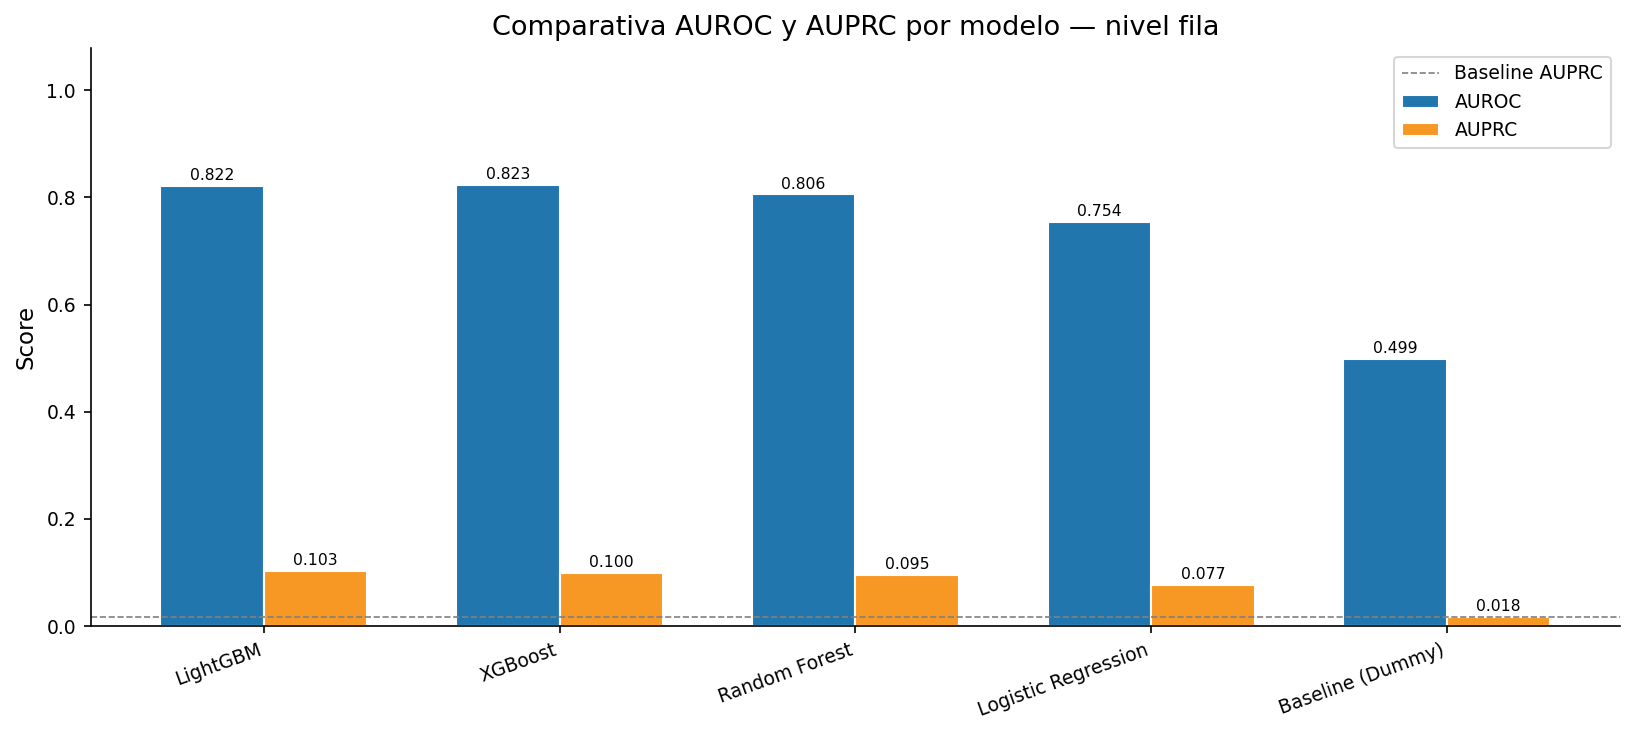

In [25]:
# Gráfico comparativo de AUROC y AUPRC a nivel fila
models_ordered = df_results_row.index.tolist()
auroc_vals = df_results_row["AUROC"].values
auprc_vals = df_results_row["AUPRC"].values

x = np.arange(len(models_ordered))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(
    x - width / 2,
    auroc_vals,
    width,
    label="AUROC",
    color=PALETTE[0],
    edgecolor="white"
)

bars2 = ax.bar(
    x + width / 2,
    auprc_vals,
    width,
    label="AUPRC",
    color=PALETTE[1],
    edgecolor="white"
)

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )

# Línea de referencia del baseline
if "Baseline (Dummy)" in df_results_row.index:
    ax.axhline(
        y=df_results_row.loc["Baseline (Dummy)", "AUPRC"],
        color="gray",
        linestyle="--",
        linewidth=0.8,
        label="Baseline AUPRC"
    )

ax.set_xticks(x)
ax.set_xticklabels(models_ordered, rotation=20, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Comparativa AUROC y AUPRC por modelo — nivel fila")
ax.legend()

plt.tight_layout()

(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_DIR / "figures" / "model_comparison_auroc_auprc_row.png",
    bbox_inches="tight",
    dpi=300,
)

plt.savefig(
    OUTPUT_DIR / "figures" / "model_comparison_auroc_auprc_row.pdf",
    bbox_inches="tight",
)

plt.show()

## Resumen de umbrales seleccionados

Los umbrales de decisión se han ajustado previamente para cada modelo utilizando predicciones out-of-fold sobre el conjunto de entrenamiento. En esta sección únicamente se resumen los umbrales seleccionados.

In [26]:
threshold_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
    ],
    "Best threshold": [
        best_threshold_lr,
        best_threshold_rf,
        best_threshold_xgb,
        best_threshold_lgbm,
    ]
})

threshold_summary.to_csv(
    OUTPUT_DIR / "metrics" / "threshold_summary.csv",
    index=False
)

threshold_summary

,Model,Best threshold
0,Logistic Regression,0.78
1,Random Forest,0.67
2,XGBoost,0.79
3,LightGBM,0.80


## Selección del modelo final
El criterio de selección para el modelo final combina varios criterios:


1.   AUPRC — métrica principal para datos desbalanceados.
2.   Recall — coste clínico de los falsos negativos
3.   Equilibrio entre precision y recall — evitar un recall alto a costa de demasiados falsos positivos.
4.   Coste computacional — relevante para un sistema en producción.


El modelo seleccionado como final es **LightGBM**.

A nivel de registro horario, que constituye la evaluación principal del sistema, LightGBM obtiene la mayor **AUPRC** (`0.1033`) y el mejor **F1-score** (`0.1820`) entre los modelos evaluados. Aunque XGBoost alcanza una AUROC ligeramente superior (`0.8233` frente a `0.8217`) y una sensibilidad algo mayor, LightGBM ofrece un mejor equilibrio entre precisión y sensibilidad, además de mejorar la métrica AUPRC, especialmente importante en escenarios con fuerte desbalance de clases.

En la evaluación complementaria a nivel de paciente, LightGBM también obtiene los mejores resultados globales, con una **AUPRC** de `0.5068`, un **F1-score** de `0.4558` y una **AUROC** de `0.8477`. Esto indica que el modelo no solo funciona de forma competitiva a nivel de registro horario, sino que también identifica con mayor fiabilidad a los pacientes que presentan sepsis en algún momento de su estancia.

Por estos motivos, se selecciona **LightGBM** como modelo final, al proporcionar el mejor compromiso entre capacidad predictiva, equilibrio entre tipos de error y rendimiento agregado.

No obstante, antes de fijar el modelo final definitivo, se analiza la importancia de variables para comprobar si el modelo depende en exceso de variables temporales o administrativas. Este paso permite valorar si alguna característica puede actuar como proxy de patrones organizativos o de trayectoria hospitalaria, en lugar de reflejar directamente el estado clínico del paciente.

In [27]:
best_model_name = "LightGBM"
final_model = models[best_model_name]
final_threshold = thresholds[best_model_name]
y_prob_final = probabilities_test[best_model_name]
y_pred_final = (y_prob_final >= final_threshold).astype(int)

print(f"Modelo final seleccionado: {best_model_name}")
print(f"Umbral final: {final_threshold:.3f}")

Modelo final seleccionado: LightGBM
Umbral final: 0.800


## Interpretabilidad
Se muestra la importancia de variables nativa del modelo final.

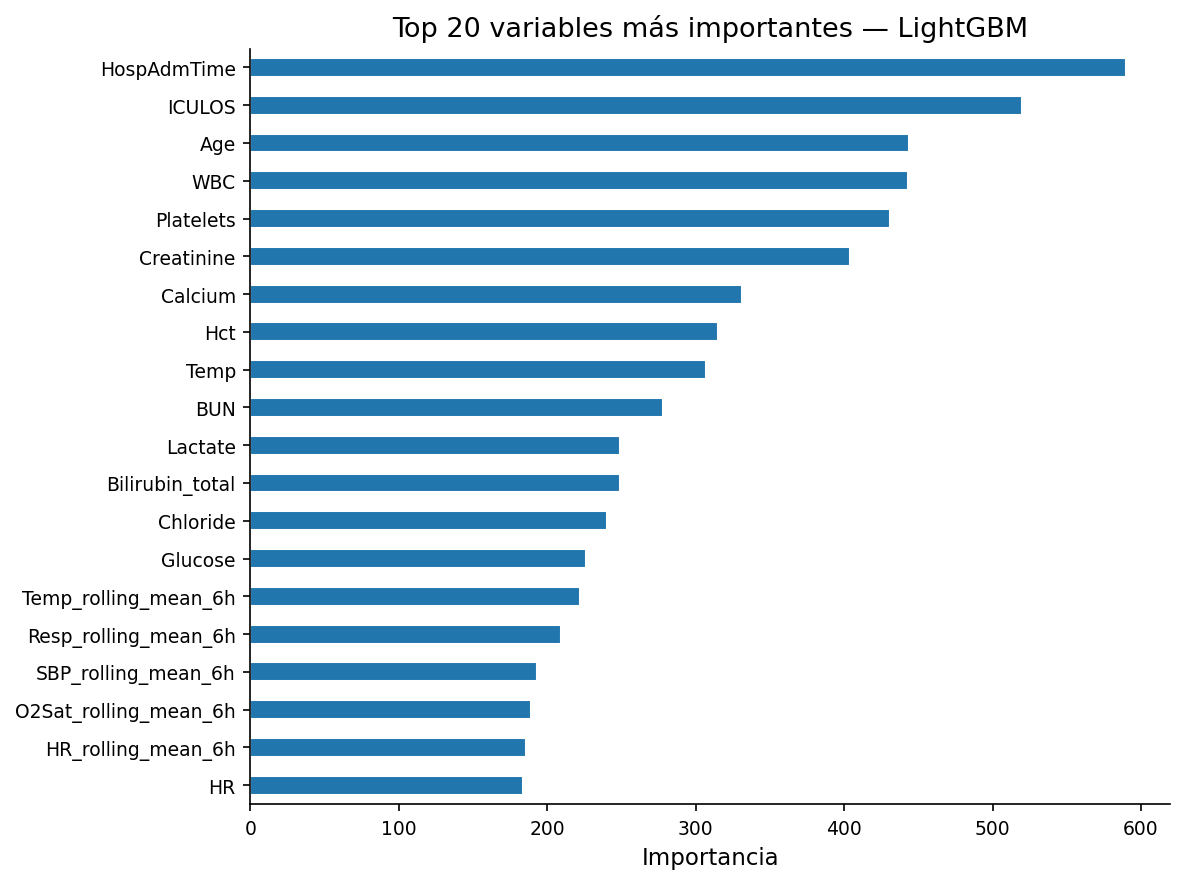

In [28]:
def get_feature_importances(model_pipeline, feature_names: list[str]) -> pd.Series | None:
    """Extrae importancia de variables del clasificador dentro de un pipeline."""
    clf = model_pipeline.named_steps.get("clf")
    if clf is None:
        return None
    if hasattr(clf, "feature_importances_"):
        return pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    if hasattr(clf, "coef_"):
        return pd.Series(np.abs(clf.coef_[0]), index=feature_names).sort_values(ascending=False)
    return None


importances = get_feature_importances(final_model, feature_cols)

if importances is not None:
    top_n = 20
    top_features = importances.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))
    top_features[::-1].plot.barh(ax=ax, color=PALETTE[0], edgecolor="white")
    ax.set_xlabel("Importancia")
    ax.set_title(f"Top {top_n} variables más importantes — {best_model_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / "feature_importances.png", bbox_inches="tight")
    plt.show()
else:
    print("El modelo final no expone importancia de variables directamente.")

Aunque `HospAdmTime` estaba disponible en el conjunto de datos, se observó que adquiría una importancia elevada en el modelo. Dado que se trata de una variable temporal-administrativa y no de una variable clínica directa, se realizó un experimento de ablación eliminándola del conjunto de predictores. Esta decisión permite reducir la dependencia del modelo respecto a posibles patrones de organización asistencial o duración previa del ingreso hospitalario.

In [61]:
# ============================================================
# Ablation study: LightGBM sin HospAdmTime
# ============================================================

feature_cols_no_hosp = [
    col for col in feature_cols
    if col != "HospAdmTime"
]

X_train_no_hosp = df_train[feature_cols_no_hosp]
X_test_no_hosp = df_test[feature_cols_no_hosp]

start_time_retrain = time.time()

best_lgbm_no_hosp = Pipeline([
    ("clf", lgb.LGBMClassifier(
        **{k.replace("clf__", ""): v for k, v in best_params_lgbm.items()},
        is_unbalance=True,
        random_state=RANDOM_STATE,
        n_jobs=2,
        verbose=-1,
    )),
])

best_lgbm_no_hosp.fit(X_train_no_hosp, y_train)

retrain_time_no_hosp = time.time() - start_time_retrain
print(f"Reentrenamiento sin HospAdmTime: {retrain_time_no_hosp:.2f} segundos")

# Predicciones OOF para ajustar umbral
y_prob_no_hosp_oof = cross_val_predict(
    best_lgbm_no_hosp,
    X_train_no_hosp,
    y_train,
    cv=GroupKFold(n_splits=N_FOLDS),
    groups=groups,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

best_threshold_no_hosp, threshold_scores_no_hosp = find_best_threshold_row(
    y_true=y_train,
    y_prob=y_prob_no_hosp_oof,
    metric="F1"
)

print(f"Mejor umbral sin HospAdmTime: {best_threshold_no_hosp:.3f}")

# Evaluación en test
y_prob_no_hosp = best_lgbm_no_hosp.predict_proba(X_test_no_hosp)[:, 1]
y_pred_no_hosp = (y_prob_no_hosp >= best_threshold_no_hosp).astype(int)

metrics_no_hosp_row = compute_metrics_row(
    y_true=y_test,
    y_prob=y_prob_no_hosp,
    threshold=best_threshold_no_hosp
)

metrics_no_hosp_patient = compute_metrics_patient(
    df_ref=df_test,
    y_prob=y_prob_no_hosp,
    threshold=best_threshold_no_hosp
)

print("\nMétricas LightGBM sin HospAdmTime a nivel fila/test:")
for k, v in metrics_no_hosp_row.items():
    print(f"  {k}: {v}")

print("\nMétricas LightGBM sin HospAdmTime a nivel paciente/test:")
for k, v in metrics_no_hosp_patient.items():
    print(f"  {k}: {v}")

Reentrenamiento sin HospAdmTime: 33.46 segundos
Mejor umbral sin HospAdmTime: 0.790

Métricas LightGBM sin HospAdmTime a nivel fila/test:
  Accuracy: 0.9447
  Precision: 0.1218
  Recall: 0.3387
  Specificity: 0.9557
  F1: 0.1791
  AUROC: 0.821
  AUPRC: 0.1055
  n_rows: 311614
  n_positivos: 5553

Métricas LightGBM sin HospAdmTime a nivel paciente/test:
  Accuracy: 0.912
  Precision: 0.4132
  Recall: 0.5034
  Specificity: 0.944
  F1: 0.4538
  AUROC: 0.8463
  AUPRC: 0.5166
  n_patients: 8068
  n_positivos: 586


In [30]:
ablation_comparison_row = pd.DataFrame({
    "LightGBM original": all_results_row["LightGBM"],
    "LightGBM sin HospAdmTime": metrics_no_hosp_row,
}).T

ablation_comparison_patient = pd.DataFrame({
    "LightGBM original": all_results_patient["LightGBM"],
    "LightGBM sin HospAdmTime": metrics_no_hosp_patient,
}).T

display(ablation_comparison_row)
display(ablation_comparison_patient)

,Accuracy,Precision,Recall,Specificity,F1,AUROC,AUPRC,n_rows,n_positivos
LightGBM original,0.9502,0.1287,0.3108,0.9618,0.1820,0.8217,0.1033,311614.0,5553.0
LightGBM sin HospAdmTime,0.9447,0.1218,0.3387,0.9557,0.1791,0.8210,0.1055,311614.0,5553.0


,Accuracy,Precision,Recall,Specificity,F1,AUROC,AUPRC,n_patients,n_positivos
LightGBM original,0.9168,0.4343,0.4795,0.9511,0.4558,0.8477,0.5068,8068.0,586.0
LightGBM sin HospAdmTime,0.9120,0.4132,0.5034,0.9440,0.4538,0.8463,0.5166,8068.0,586.0


## Selección definitiva del modelo final tras ablación

Tras analizar la importancia de variables del modelo LightGBM, se observó que `HospAdmTime` adquiría un peso elevado. Dado que esta variable representa información temporal-administrativa relacionada con el tiempo transcurrido entre el ingreso hospitalario y el ingreso en UCI, se realizó un experimento de ablación eliminándola del conjunto de predictores.

La eliminación de `HospAdmTime` no deterioró el rendimiento del modelo; al contrario, produjo una ligera mejora en AUPRC tanto a nivel de registro horario como a nivel de paciente. Por este motivo, se selecciona como modelo final definitivo la variante LightGBM sin `HospAdmTime`.

In [31]:
# ============================================================
# Modelo final definitivo tras ablación
# ============================================================

best_model_name = "LightGBM sin HospAdmTime"

final_model = best_lgbm_no_hosp
final_threshold = best_threshold_no_hosp
y_prob_final = y_prob_no_hosp
y_pred_final = y_pred_no_hosp
feature_cols_final = feature_cols_no_hosp

all_results_row[best_model_name] = metrics_no_hosp_row
all_results_patient[best_model_name] = metrics_no_hosp_patient
models[best_model_name] = final_model
probabilities_test[best_model_name] = y_prob_final
thresholds[best_model_name] = final_threshold

print(f"Modelo final definitivo: {best_model_name}")
print(f"Umbral final: {final_threshold:.3f}")

print("\nMétricas finales a nivel fila:")
for k, v in metrics_no_hosp_row.items():
    print(f"  {k}: {v}")

print("\nMétricas finales a nivel paciente:")
for k, v in metrics_no_hosp_patient.items():
    print(f"  {k}: {v}")

Modelo final definitivo: LightGBM sin HospAdmTime
Umbral final: 0.790

Métricas finales a nivel fila:
  Accuracy: 0.9447
  Precision: 0.1218
  Recall: 0.3387
  Specificity: 0.9557
  F1: 0.1791
  AUROC: 0.821
  AUPRC: 0.1055
  n_rows: 311614
  n_positivos: 5553

Métricas finales a nivel paciente:
  Accuracy: 0.912
  Precision: 0.4132
  Recall: 0.5034
  Specificity: 0.944
  F1: 0.4538
  AUROC: 0.8463
  AUPRC: 0.5166
  n_patients: 8068
  n_positivos: 586


## Análisis de interpretabilidad modelo final

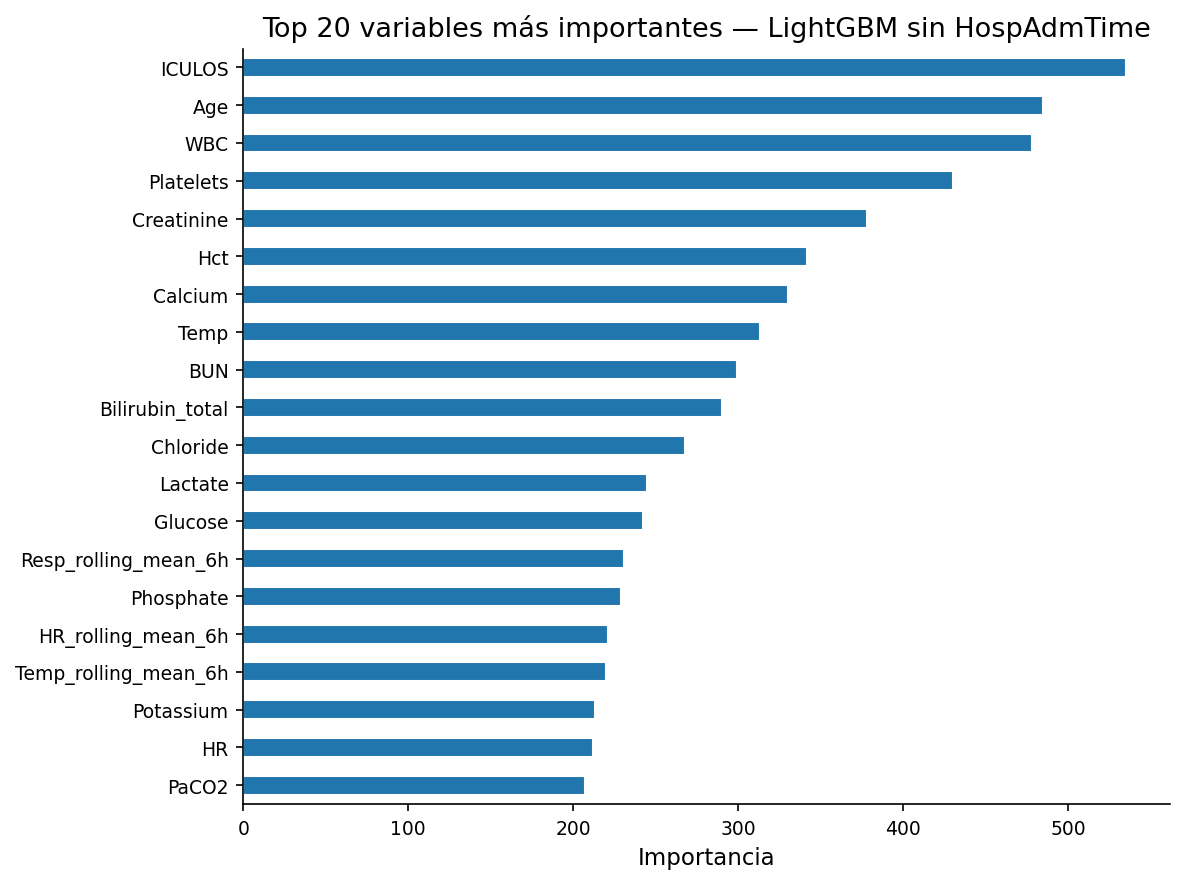

In [33]:
def get_feature_importances(model_pipeline, feature_names: list[str]) -> pd.Series | None:
    """Extrae importancia de variables del clasificador dentro de un pipeline."""
    clf = model_pipeline.named_steps.get("clf")
    if clf is None:
        return None
    if hasattr(clf, "feature_importances_"):
        return pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    if hasattr(clf, "coef_"):
        return pd.Series(np.abs(clf.coef_[0]), index=feature_names).sort_values(ascending=False)
    return None


importances = get_feature_importances(final_model, feature_cols_no_hosp)

if importances is not None:
    top_n = 20
    top_features = importances.head(top_n)

    fig, ax = plt.subplots(figsize=(8, 6))
    top_features[::-1].plot.barh(ax=ax, color=PALETTE[0], edgecolor="white")
    ax.set_xlabel("Importancia")
    ax.set_title(f"Top {top_n} variables más importantes — {best_model_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / "feature_importances.png", bbox_inches="tight")
    plt.show()
else:
    print("El modelo final no expone importancia de variables directamente.")

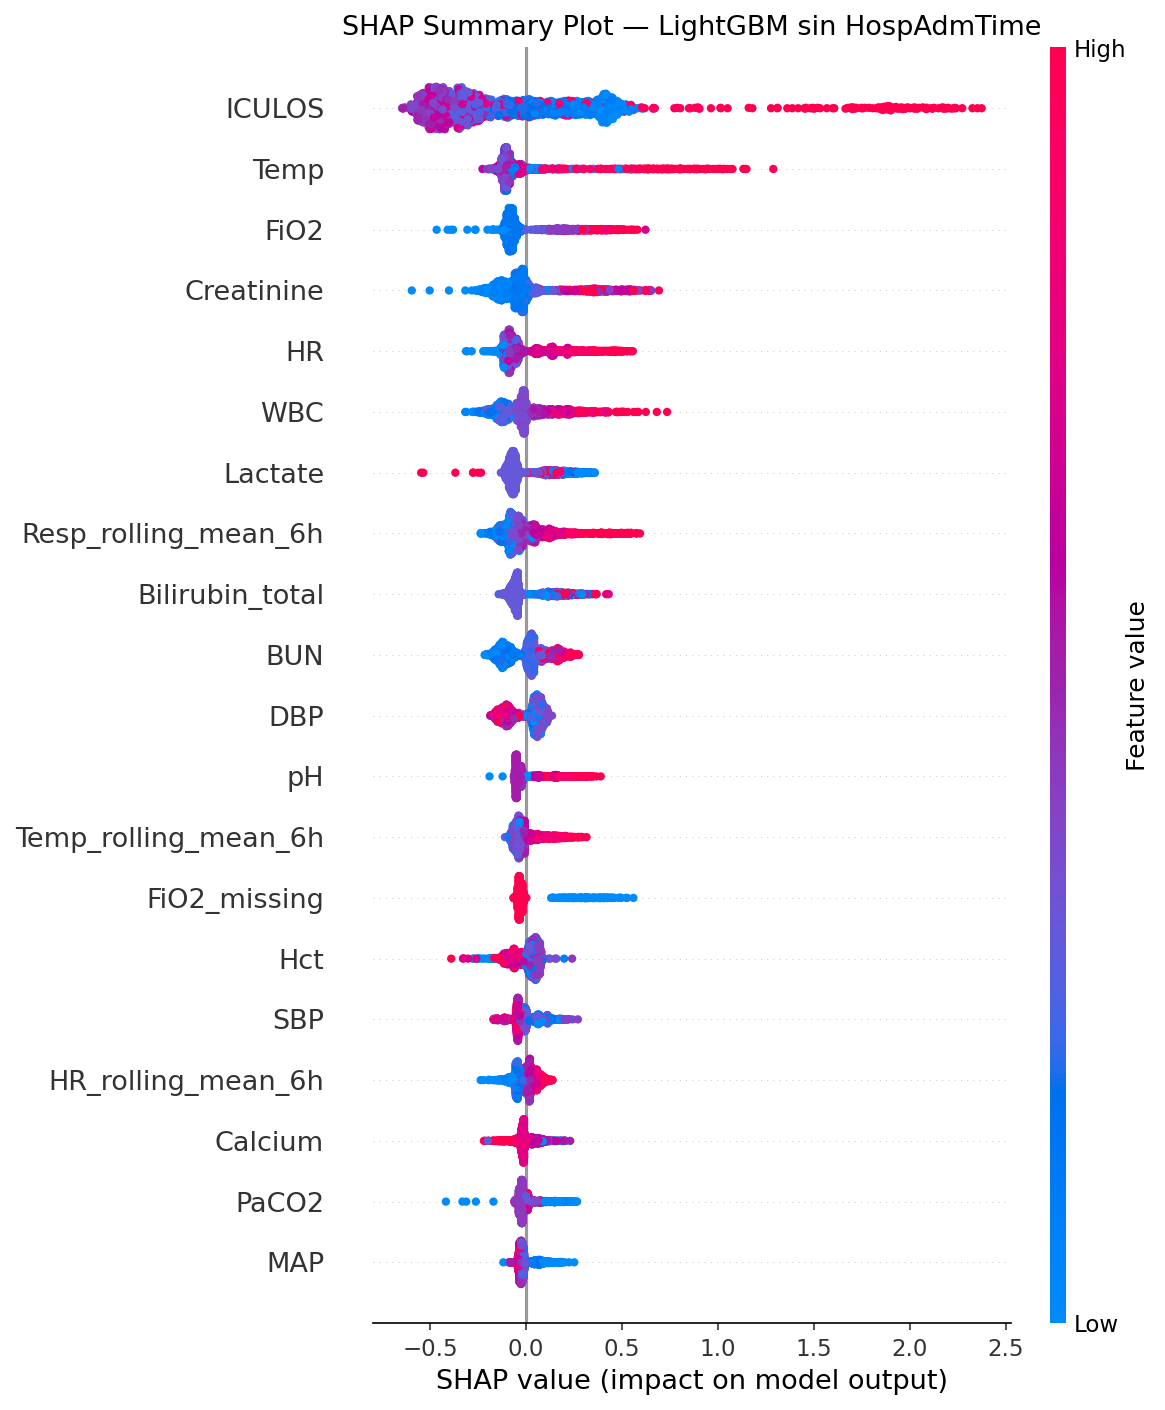

In [34]:
# ============================================================
# SHAP — interpretación del modelo final
# ============================================================

try:
    import shap

    clf_for_shap = final_model.named_steps["clf"]

    # Usar las columnas exactas con las que se entrenó el modelo final
    X_test_final = df_test[feature_cols_final].copy()

    # Si el pipeline incluye transformaciones previas, aplicarlas
    if len(final_model.steps) > 1 and "clf" in final_model.named_steps:
        preprocessing_steps = final_model.steps[:-1]

        if len(preprocessing_steps) > 0:
            X_tmp = X_test_final.copy()

            for step_name, step_obj in preprocessing_steps:
                X_tmp = step_obj.transform(X_tmp)

            X_shap = pd.DataFrame(
                X_tmp,
                columns=feature_cols_final
            )
        else:
            X_shap = X_test_final.copy()
    else:
        X_shap = X_test_final.copy()

    # Muestra para agilizar el cálculo
    sample_size = min(2000, len(X_shap))
    X_shap_sample = X_shap.sample(
        n=sample_size,
        random_state=RANDOM_STATE
    )

    # Asegurar que no hay columnas problemáticas
    X_shap_sample = X_shap_sample.astype(float)

    # SHAP para modelos de árbol
    explainer = shap.TreeExplainer(clf_for_shap)
    shap_values = explainer.shap_values(X_shap_sample)

    # Compatibilidad entre versiones de SHAP/modelos binarios
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    elif hasattr(shap_values, "values"):
        shap_values_plot = shap_values.values
        if shap_values_plot.ndim == 3:
            shap_values_plot = shap_values_plot[:, :, 1]
    else:
        shap_values_plot = shap_values

    # Si todavía queda 3D, coger clase positiva
    if len(shap_values_plot.shape) == 3:
        shap_values_plot = shap_values_plot[:, :, 1]

    plt.figure(figsize=(8, 6))

    shap.summary_plot(
        shap_values_plot,
        X_shap_sample,
        show=False,
        max_display=20
    )

    plt.title(f"SHAP Summary Plot — {best_model_name}")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "figures" / "shap_summary_final_model.png",
        bbox_inches="tight",
        dpi=300
    )

    plt.savefig(
        OUTPUT_DIR / "figures" / "shap_summary_final_model.pdf",
        bbox_inches="tight"
    )

    plt.show()

except Exception as e:
    print(f"SHAP no disponible para este modelo: {e}")

## Evaluación final del modelo seleccionado

### Matriz de confusión

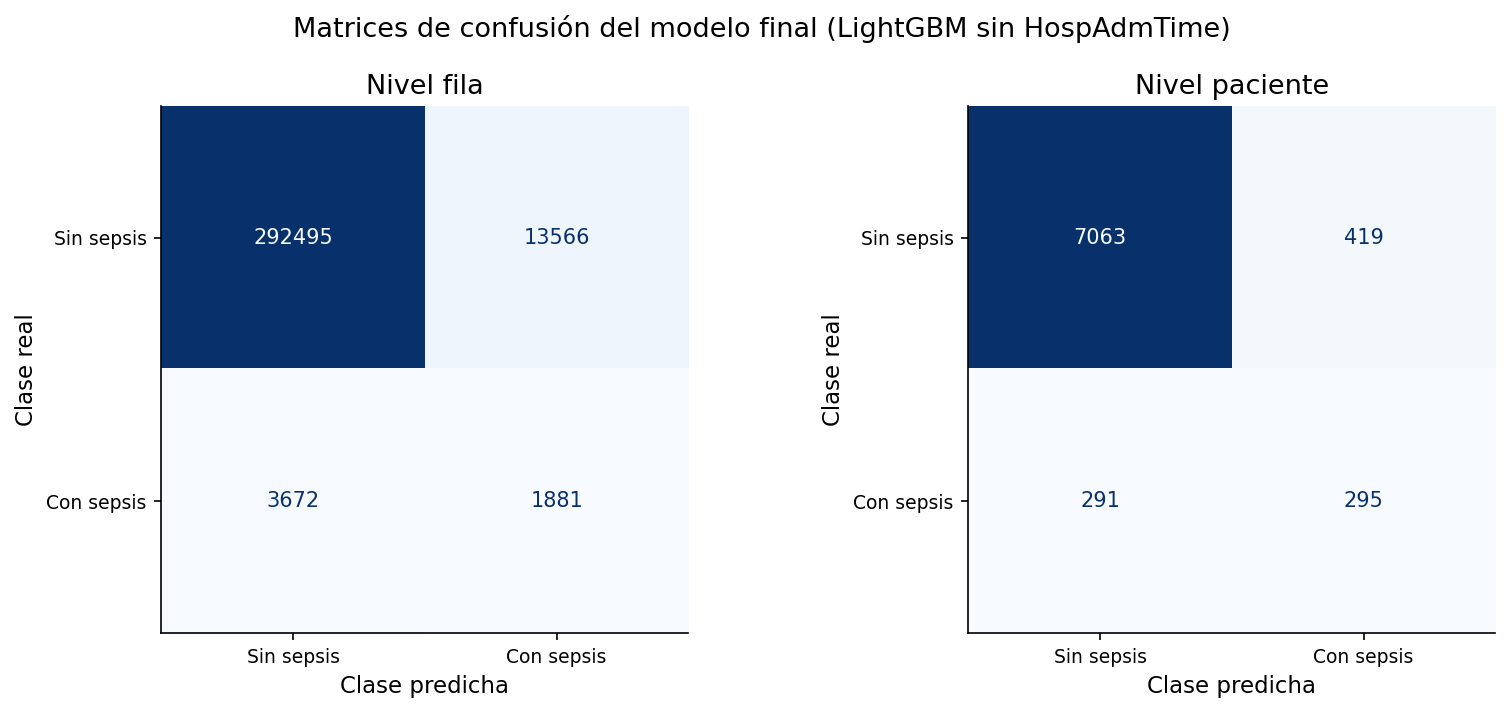

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# Matrices de confusión absolutas — modelo final
# ============================================================

cm_row = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[0, 1]
)



df_eval_patient = df_test[["PatientID", TARGET_COL]].copy()
df_eval_patient["y_prob"] = y_prob_final

df_patient_eval = (
    df_eval_patient
    .groupby("PatientID")
    .agg(
        y_true=(TARGET_COL, "max"),
        y_prob=("y_prob", "max")
    )
    .reset_index()
)

y_true_patient = df_patient_eval["y_true"].values
y_prob_patient = df_patient_eval["y_prob"].values
y_pred_patient = (y_prob_patient >= final_threshold).astype(int)

cm_patient = confusion_matrix(
    y_true_patient,
    y_pred_patient,
    labels=[0, 1]
)



fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

disp_row = ConfusionMatrixDisplay(
    confusion_matrix=cm_row,
    display_labels=["Sin sepsis", "Con sepsis"]
)

disp_row.plot(
    ax=axes[0],
    colorbar=False,
    cmap="Blues",
    values_format="d"
)

axes[0].set_title("Nivel fila")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")


disp_patient = ConfusionMatrixDisplay(
    confusion_matrix=cm_patient,
    display_labels=["Sin sepsis", "Con sepsis"]
)

disp_patient.plot(
    ax=axes[1],
    colorbar=False,
    cmap="Blues",
    values_format="d"
)

axes[1].set_title("Nivel paciente")
axes[1].set_xlabel("Clase predicha")
axes[1].set_ylabel("Clase real")

fig.suptitle(
    f"Matrices de confusión del modelo final ({best_model_name})",
    fontsize=13
)

plt.tight_layout()

(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_DIR / "figures" / "confusion_matrix_row_patient_absolute.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    OUTPUT_DIR / "figures" / "confusion_matrix_row_patient_absolute.pdf",
    bbox_inches="tight"
)

plt.show()

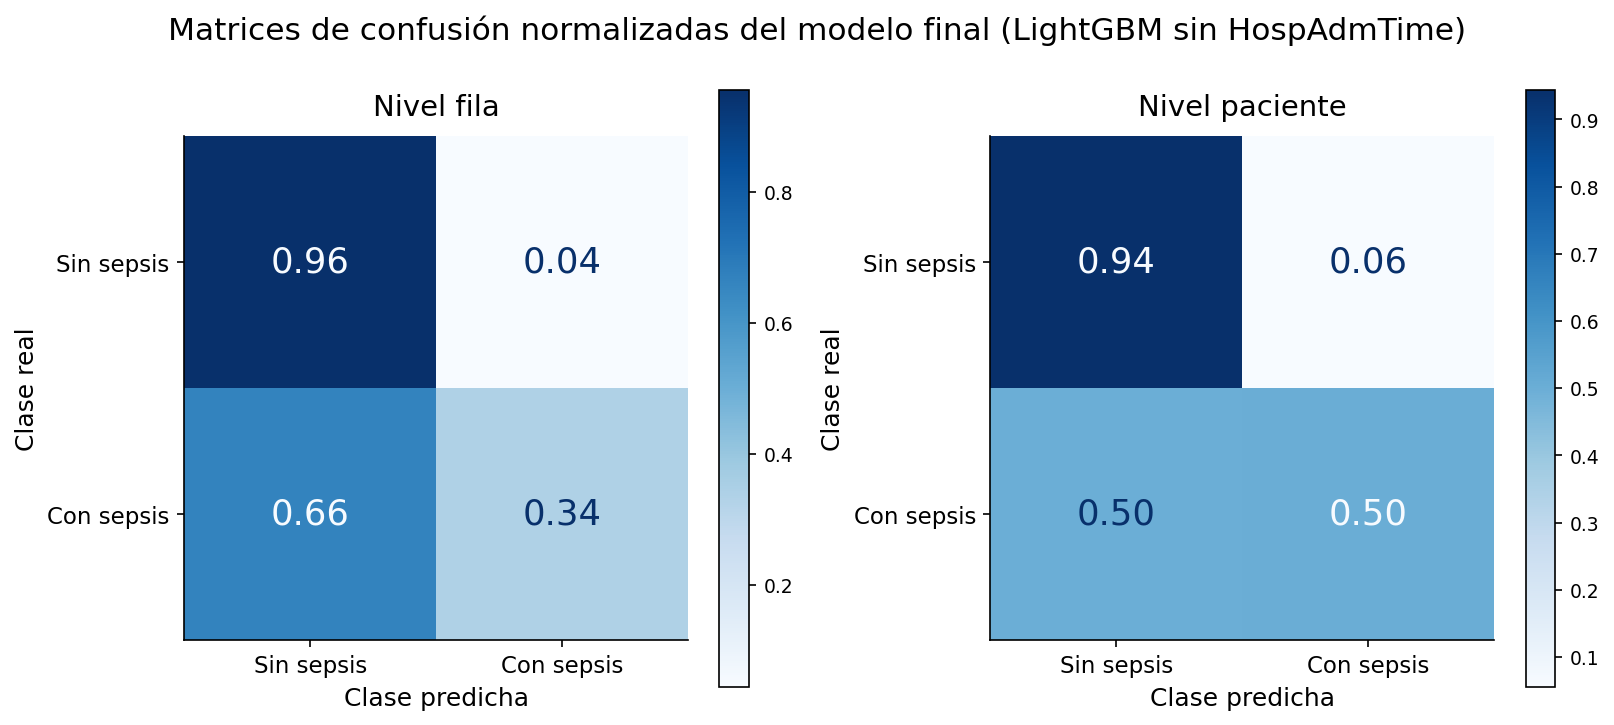

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ============================================================
# Matrices de confusión normalizadas — modelo final
# ============================================================

cm_row_norm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[0, 1],
    normalize="true"
)

cm_patient_norm = confusion_matrix(
    y_true_patient,
    y_pred_patient,
    labels=[0, 1],
    normalize="true"
)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# --- GRÁFICO 1: NIVEL FILA ---
disp_row_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_row_norm,
    display_labels=["Sin sepsis", "Con sepsis"]
)
disp_row_norm.plot(
    ax=axes[0],
    colorbar=True,
    cmap="Blues",
    values_format=".2f",
    text_kw={"fontsize": 17}
)

axes[0].set_title("Nivel fila", fontsize=14, pad=10)
axes[0].set_xlabel("Clase predicha", fontsize=12)
axes[0].set_ylabel("Clase real", fontsize=12)
axes[0].tick_params(axis='both', which='major', labelsize=11)

# --- GRÁFICO 2: NIVEL PACIENTE ---
disp_patient_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_patient_norm,
    display_labels=["Sin sepsis", "Con sepsis"]
)
disp_patient_norm.plot(
    ax=axes[1],
    colorbar=True,
    cmap="Blues",
    values_format=".2f",
    text_kw={"fontsize": 17}
)

axes[1].set_title("Nivel paciente", fontsize=14, pad=10)
axes[1].set_xlabel("Clase predicha", fontsize=12)
axes[1].set_ylabel("Clase real", fontsize=12)
axes[1].tick_params(axis='both', which='major', labelsize=11)

# --- TÍTULO GLOBAL ---
fig.suptitle(
    f"Matrices de confusión normalizadas del modelo final ({best_model_name})",
    fontsize=15,
    y=1
)

plt.tight_layout()

# Guardar y mostrar
plt.savefig(
    OUTPUT_DIR / "figures" / "confusion_matrix_row_patient_normalized.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    OUTPUT_DIR / "figures" / "confusion_matrix_row_patient_normalized.pdf",
    bbox_inches="tight"
)

plt.show()

## Curvas comparativas de los modelos

Además de las métricas tabulares, se representan las curvas ROC y Precision-Recall de los modelos evaluados. La curva ROC permite analizar la capacidad discriminativa global, mientras que la curva Precision-Recall resulta especialmente relevante en este problema debido al fuerte desbalance de clases.

### Curva ROC

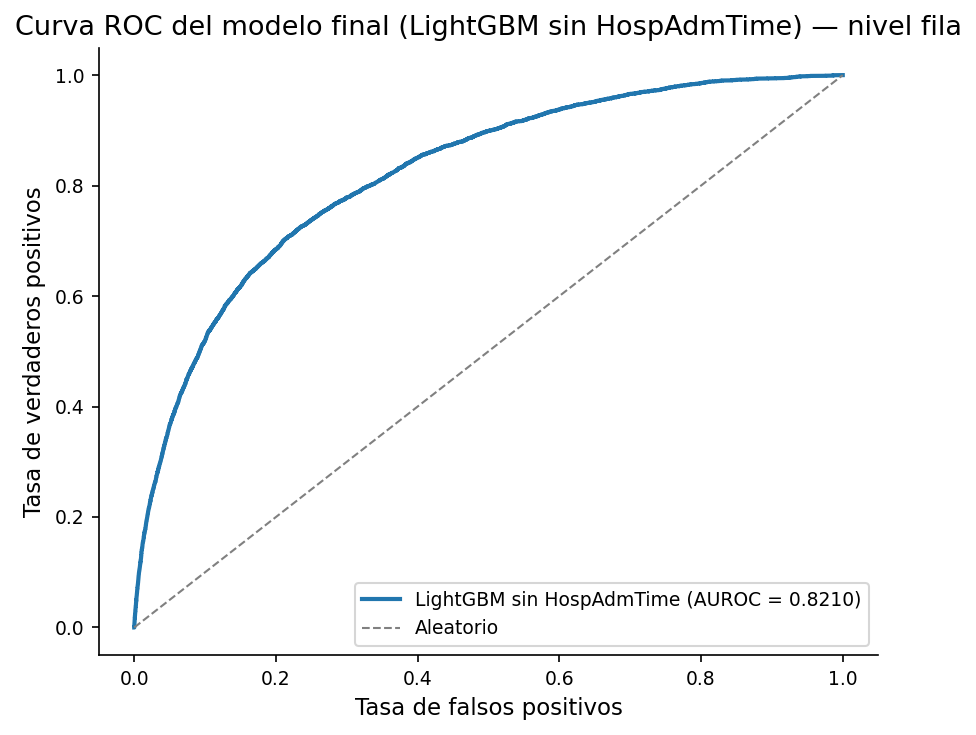

In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob_final)
auroc = roc_auc_score(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    fpr,
    tpr,
    color=PALETTE[0],
    linewidth=2,
    label=f"{best_model_name} (AUROC = {auroc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Aleatorio"
)

ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title(f"Curva ROC del modelo final ({best_model_name}) — nivel fila")
ax.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figures" / "roc_curve_final_model.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    OUTPUT_DIR / "figures" / "roc_curve_final_model.pdf",
    bbox_inches="tight"
)

plt.show()

### Curva Precision-Recall

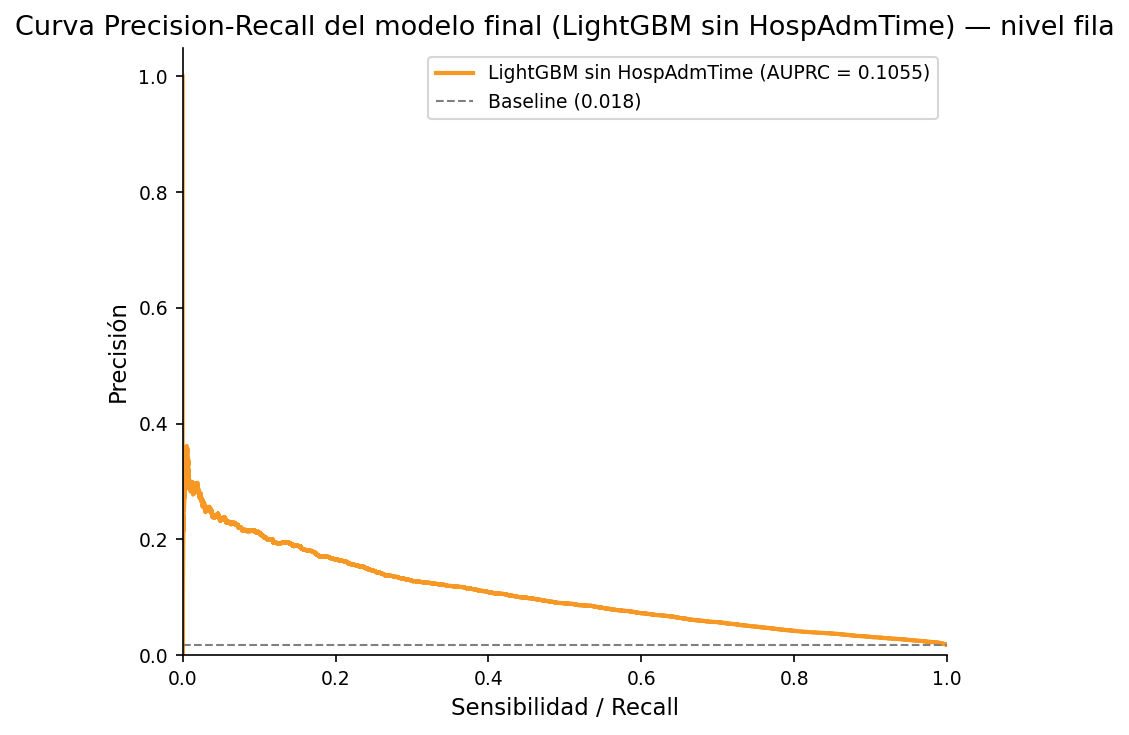

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob_final
)

auprc = average_precision_score(y_test, y_prob_final)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(
    recall_curve,
    precision_curve,
    color=PALETTE[1],
    linewidth=2,
    label=f"{best_model_name} (AUPRC = {auprc:.4f})"
)

ax.axhline(
    y=baseline_pr,
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Baseline ({baseline_pr:.3f})"
)

ax.set_xlabel("Sensibilidad / Recall")
ax.set_ylabel("Precisión")
ax.set_title(f"Curva Precision-Recall del modelo final ({best_model_name}) — nivel fila")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figures" / "precision_recall_curve_final_model.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    OUTPUT_DIR / "figures" / "precision_recall_curve_final_model.pdf",
    bbox_inches="tight"
)

plt.show()

### Curvas ROC y PR comparativas de todos los modelos

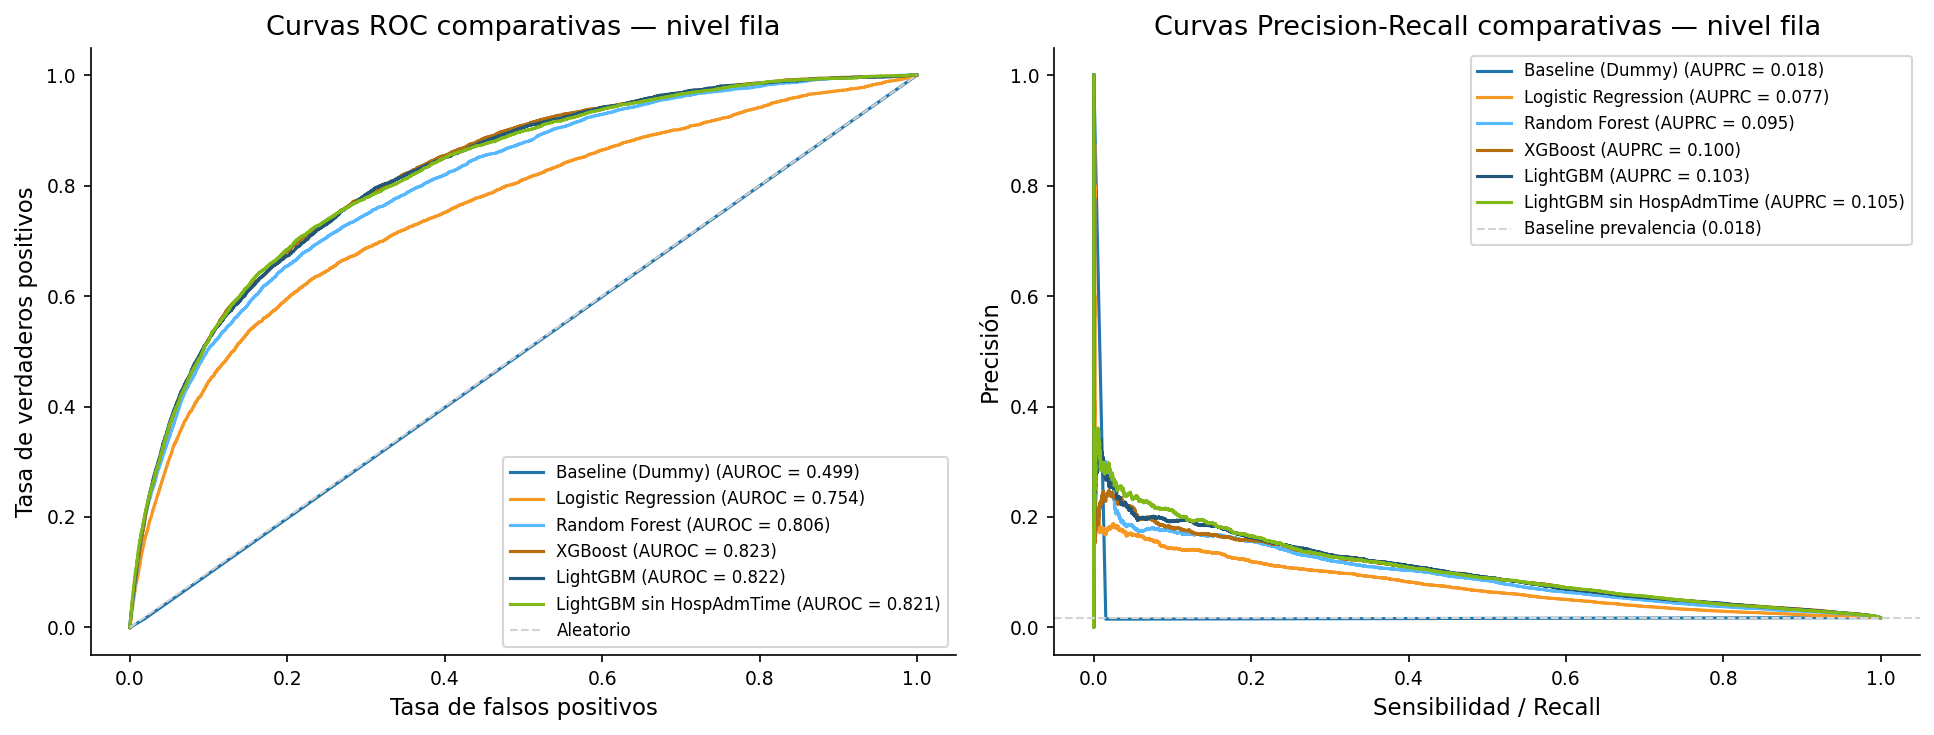

In [39]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# Usar solo modelos que existan en probabilities_test
prob_map = {
    name: probs
    for name, probs in probabilities_test.items()
    if name != "Baseline (Dummy)"
}

# Añadir baseline si quieres que aparezca también en las curvas
if "Baseline (Dummy)" in probabilities_test:
    prob_map = {
        "Baseline (Dummy)": probabilities_test["Baseline (Dummy)"],
        **prob_map
    }

baseline_pr = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (name, probs) in enumerate(prob_map.items()):
    color = PALETTE[i % len(PALETTE)]

    # Curva ROC
    fpr_i, tpr_i, _ = roc_curve(y_test, probs)
    auroc_i = roc_auc_score(y_test, probs)

    axes[0].plot(
        fpr_i,
        tpr_i,
        color=color,
        linewidth=1.5,
        label=f"{name} (AUROC = {auroc_i:.3f})"
    )

    # Curva Precision-Recall
    prec_i, rec_i, _ = precision_recall_curve(y_test, probs)
    auprc_i = average_precision_score(y_test, probs)

    axes[1].plot(
        rec_i,
        prec_i,
        color=color,
        linewidth=1.5,
        label=f"{name} (AUPRC = {auprc_i:.3f})"
    )

# Línea aleatoria ROC
axes[0].plot(
    [0, 1],
    [0, 1],
    color="lightgray",
    linestyle="--",
    linewidth=1,
    label="Aleatorio"
)

axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curvas ROC comparativas — nivel fila")
axes[0].legend(fontsize=8)

# Baseline PR = prevalencia clase positiva
axes[1].axhline(
    y=baseline_pr,
    color="lightgray",
    linestyle="--",
    linewidth=1,
    label=f"Baseline prevalencia ({baseline_pr:.3f})"
)

axes[1].set_xlabel("Sensibilidad / Recall")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curvas Precision-Recall comparativas — nivel fila")
axes[1].legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figures" / "all_models_roc_pr.png",
    bbox_inches="tight",
    dpi=300
)

plt.savefig(
    OUTPUT_DIR / "figures" / "all_models_roc_pr.pdf",
    bbox_inches="tight"
)

plt.show()

## Análisis de errores

El análisis de errores se centra en los falsos negativos y falsos positivos del modelo final. Los falsos negativos representan registros asociados a sepsis que no fueron detectados, mientras que los falsos positivos corresponden a registros sin sepsis que habrían generado una alerta. Este análisis permite estudiar si los errores se concentran cerca del umbral de decisión y qué características clínicas presentan.

In [40]:
df_test_analysis = df_test.copy()
df_test_analysis["y_pred"] = y_pred_final
df_test_analysis["y_prob"] = y_prob_final

df_fn = df_test_analysis[
    (df_test_analysis[TARGET_COL] == 1) &
    (df_test_analysis["y_pred"] == 0)
].copy()

df_fp = df_test_analysis[
    (df_test_analysis[TARGET_COL] == 0) &
    (df_test_analysis["y_pred"] == 1)
].copy()

df_tp = df_test_analysis[
    (df_test_analysis[TARGET_COL] == 1) &
    (df_test_analysis["y_pred"] == 1)
].copy()

df_tn = df_test_analysis[
    (df_test_analysis[TARGET_COL] == 0) &
    (df_test_analysis["y_pred"] == 0)
].copy()

In [41]:
error_prob_summary = pd.DataFrame({
    "Grupo": ["FN", "FP", "TP", "TN"],
    "n_registros": [len(df_fn), len(df_fp), len(df_tp), len(df_tn)],
    "prob_media": [
        df_fn["y_prob"].mean(),
        df_fp["y_prob"].mean(),
        df_tp["y_prob"].mean(),
        df_tn["y_prob"].mean(),
    ],
    "prob_mediana": [
        df_fn["y_prob"].median(),
        df_fp["y_prob"].median(),
        df_tp["y_prob"].median(),
        df_tn["y_prob"].median(),
    ],
    "prob_q25": [
        df_fn["y_prob"].quantile(0.25),
        df_fp["y_prob"].quantile(0.25),
        df_tp["y_prob"].quantile(0.25),
        df_tn["y_prob"].quantile(0.25),
    ],
    "prob_q75": [
        df_fn["y_prob"].quantile(0.75),
        df_fp["y_prob"].quantile(0.75),
        df_tp["y_prob"].quantile(0.75),
        df_tn["y_prob"].quantile(0.75),
    ],
})

display(error_prob_summary)

,Grupo,n_registros,prob_media,prob_mediana,prob_q25,prob_q75
0,FN,3672,0.491139,0.494239,0.349377,0.645181
1,FP,13566,0.855081,0.853219,0.825211,0.882749
2,TP,1881,0.870890,0.873906,0.839495,0.902368
3,TN,292495,0.306335,0.272578,0.172498,0.403781


In [42]:
clinical_cols_error = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "Resp",
    "Lactate", "WBC", "Creatinine", "Platelets",
    "Age", "ICULOS"
]

clinical_cols_error = [
    col for col in clinical_cols_error
    if col in df_test_analysis.columns
]

error_groups = {
    "FN": df_fn,
    "FP": df_fp,
    "TP": df_tp,
    "TN": df_tn,
}

clinical_error_summary = []

for group_name, df_group in error_groups.items():
    row = {"Grupo": group_name, "n_registros": len(df_group)}

    for col in clinical_cols_error:
        row[f"{col}_mediana"] = df_group[col].median()

    clinical_error_summary.append(row)

clinical_error_summary = pd.DataFrame(clinical_error_summary)

display(clinical_error_summary)

,Grupo,n_registros,HR_mediana,O2Sat_mediana,Temp_mediana,SBP_mediana,MAP_mediana,Resp_mediana,Lactate_mediana,WBC_mediana,Creatinine_mediana,Platelets_mediana,Age_mediana,ICULOS_mediana
0,FN,3672,87.0,98.0,36.83,121.0,78.0,19.0,1.58,10.3,0.9,189.0,62.76,19.0
1,FP,13566,90.0,97.0,37.17,120.0,78.5,20.0,1.58,11.8,1.0,191.0,66.33,95.0
2,TP,1881,91.0,97.0,37.44,121.0,78.0,21.0,1.51,11.9,0.9,195.0,66.00,96.0
3,TN,292495,83.0,98.0,36.83,121.0,81.0,18.0,1.58,10.3,0.9,189.0,64.00,20.0


In [43]:
df_fn_near_threshold = (
    df_fn
    .sort_values("y_prob", ascending=False)
    [["PatientID", "TimeStep", TARGET_COL, "y_pred", "y_prob"] + clinical_cols_error]
    .head(10)
)

display(df_fn_near_threshold)

,PatientID,TimeStep,SepsisLabel,y_pred,y_prob,HR,O2Sat,Temp,SBP,MAP,Resp,Lactate,WBC,Creatinine,Platelets,Age,ICULOS
80916,A_p010491,95,1,0,0.789996,97.0,100.0,36.06,125.0,90.33,35.0,0.90,11.0,0.60,153.0,19.25,95
101148,A_p012970,9,1,0,0.789886,134.0,93.0,38.89,114.0,81.33,24.0,1.90,10.3,0.70,189.0,62.23,9
91260,A_p011751,209,1,0,0.789799,74.0,99.0,37.28,157.0,114.00,24.0,1.80,23.6,0.40,467.0,52.51,209
151294,A_p019547,103,1,0,0.789691,87.0,100.0,36.67,100.0,69.00,15.0,1.58,6.8,0.50,229.0,80.50,103
238116,B_p110194,11,1,0,0.789684,129.0,100.0,37.30,111.0,71.00,18.0,1.58,13.3,2.57,292.0,73.00,11
26746,A_p003455,102,1,0,0.789544,73.0,98.0,36.72,170.0,79.00,13.0,1.30,15.5,4.10,90.0,66.19,106
26750,A_p003455,106,1,0,0.789544,75.0,99.0,36.67,170.0,79.00,15.0,1.30,15.5,4.10,90.0,66.19,110
116642,A_p015160,17,1,0,0.789482,113.0,94.0,38.44,120.0,78.00,12.0,1.58,16.5,0.30,498.0,53.17,18
73143,A_p009433,55,1,0,0.789459,94.0,99.0,37.50,128.0,72.00,26.0,1.40,15.8,1.60,205.0,72.66,55
29306,A_p003729,96,1,0,0.789360,96.0,99.0,37.78,136.0,85.00,20.0,1.58,10.5,0.50,233.0,77.38,97


In [44]:
df_fp_high_confidence = (
    df_fp
    .sort_values("y_prob", ascending=False)
    [["PatientID", "TimeStep", TARGET_COL, "y_pred", "y_prob"] + clinical_cols_error]
    .head(10)
)

display(df_fp_high_confidence)

,PatientID,TimeStep,SepsisLabel,y_pred,y_prob,HR,O2Sat,Temp,SBP,MAP,Resp,Lactate,WBC,Creatinine,Platelets,Age,ICULOS
223895,B_p108574,95,0,1,0.965982,126.0,95.0,37.2,163.0,100.0,28.0,0.86,17.2,0.92,301.0,50.0,95
223863,B_p108574,63,0,1,0.965888,89.0,88.0,37.5,98.0,71.5,30.0,1.15,15.9,0.89,305.0,50.0,63
223912,B_p108574,112,0,1,0.964967,131.0,91.0,38.0,127.0,85.0,22.0,1.31,14.6,0.80,262.0,50.0,112
223894,B_p108574,94,0,1,0.964460,115.0,95.0,37.2,146.5,96.5,28.0,0.83,17.2,0.92,301.0,50.0,94
223874,B_p108574,74,0,1,0.963554,98.0,90.0,37.3,140.0,95.0,30.0,1.07,15.0,0.89,276.0,50.0,74
223897,B_p108574,97,0,1,0.963545,131.0,90.0,37.4,144.0,92.0,28.0,1.06,17.2,0.92,301.0,50.0,97
223899,B_p108574,99,0,1,0.962952,133.0,91.0,37.2,151.0,98.0,28.0,1.10,17.2,0.97,301.0,50.0,99
223902,B_p108574,102,0,1,0.962903,123.5,96.0,37.0,144.0,94.0,22.0,1.19,17.2,0.97,301.0,50.0,102
223915,B_p108574,115,0,1,0.962646,139.0,75.0,38.4,158.0,98.0,32.0,1.52,14.6,0.80,262.0,50.0,115
223867,B_p108574,67,0,1,0.961971,83.0,97.0,37.3,117.0,79.0,30.0,1.30,15.9,0.89,305.0,50.0,67


In [45]:
# Comparativa de características clínicas entre FN y FP
clinical_cols = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]
available_clinical = [c for c in clinical_cols if c in df_test_analysis.columns]

comparison = pd.DataFrame({
    "FN (media)": df_fn[available_clinical].mean(),
    "FP (media)": df_fp[available_clinical].mean(),
    "TP (media)": df_tp[available_clinical].mean(),
})

display(comparison.round(2))

,FN (media),FP (media),TP (media)
HR,88.36,91.09,91.93
O2Sat,97.17,96.67,96.43
Temp,37.00,37.17,37.40
SBP,121.52,120.97,121.67
MAP,80.80,80.59,80.94
Resp,19.59,20.59,22.00


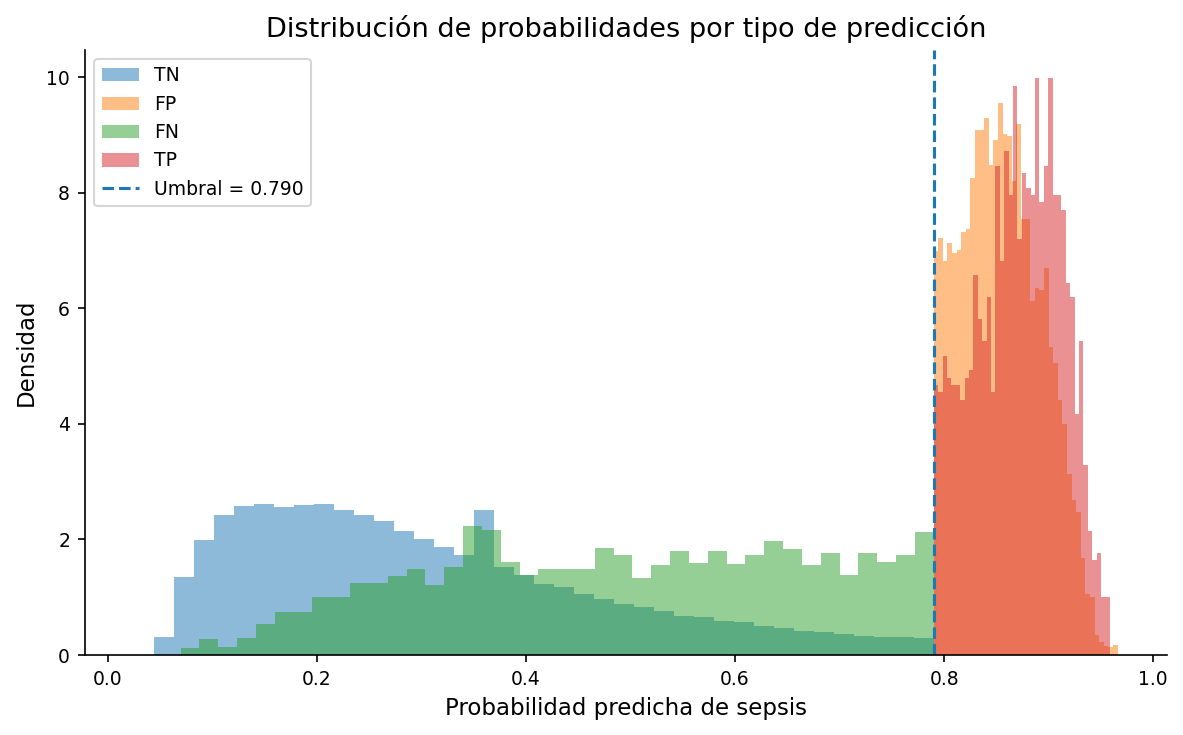

In [46]:
df_prob_plot = pd.concat([
    df_fn.assign(tipo_error="FN"),
    df_fp.assign(tipo_error="FP"),
    df_tp.assign(tipo_error="TP"),
    df_tn.assign(tipo_error="TN"),
])

fig, ax = plt.subplots(figsize=(8, 5))

for group_name in ["TN", "FP", "FN", "TP"]:
    subset = df_prob_plot[df_prob_plot["tipo_error"] == group_name]
    ax.hist(
        subset["y_prob"],
        bins=40,
        alpha=0.5,
        label=group_name,
        density=True
    )

ax.axvline(
    final_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Umbral = {final_threshold:.3f}"
)

ax.set_xlabel("Probabilidad predicha de sepsis")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de probabilidades por tipo de predicción")
ax.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figures" / "error_probability_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

Además de analizar falsos positivos y falsos negativos de forma agregada, se estudia el retraso de detección en pacientes que presentan sepsis. Para cada paciente positivo se identifica el primer instante temporal en el que `SepsisLabel=1` y se compara con el primer instante posterior en el que el modelo emite una predicción positiva. De este modo, se calcula cuántas horas tarda el modelo en detectar la sepsis desde el primer registro etiquetado como positivo.

In [58]:
# ============================================================
# Análisis de retraso en la detección de sepsis
# ============================================================

df_detection = df_test[["PatientID", "TimeStep", TARGET_COL]].copy().reset_index(drop=True)
df_detection["y_prob"] = y_prob_final
df_detection["y_pred"] = y_pred_final

# Asegurar orden temporal por paciente
df_detection = df_detection.sort_values(["PatientID", "TimeStep"]).reset_index(drop=True)


def compute_patient_detection_delay(df_patient: pd.DataFrame) -> pd.Series:
    """Calcula el retraso de detección para un paciente positivo.

    Se define:
    - onset_time: primer TimeStep con SepsisLabel=1.
    - first_detection_after_onset: primer TimeStep >= onset_time con y_pred=1.
    - delay_hours: diferencia entre ambos.
    """

    patient_id = df_patient["PatientID"].iloc[0]

    # Solo analizamos pacientes positivos
    if df_patient[TARGET_COL].max() == 0:
        return pd.Series({
            "PatientID": patient_id,
            "is_sepsis_patient": 0,
            "onset_time": np.nan,
            "first_detection_after_onset": np.nan,
            "delay_hours": np.nan,
            "detected_after_onset": False,
            "first_detection_any": np.nan,
            "early_detection": False,
            "max_prob_after_onset": np.nan,
            "n_positive_rows": 0,
        })

    onset_time = df_patient.loc[
        df_patient[TARGET_COL] == 1,
        "TimeStep"
    ].min()

    df_after_onset = df_patient[df_patient["TimeStep"] >= onset_time]

    detected_after = df_after_onset[df_after_onset["y_pred"] == 1]

    if len(detected_after) > 0:
        first_detection_after_onset = detected_after["TimeStep"].min()
        delay_hours = first_detection_after_onset - onset_time
        detected_after_onset = True
    else:
        first_detection_after_onset = np.nan
        delay_hours = np.nan
        detected_after_onset = False

    detected_any = df_patient[df_patient["y_pred"] == 1]

    if len(detected_any) > 0:
        first_detection_any = detected_any["TimeStep"].min()
        early_detection = first_detection_any < onset_time
    else:
        first_detection_any = np.nan
        early_detection = False

    return pd.Series({
        "PatientID": patient_id,
        "is_sepsis_patient": 1,
        "onset_time": onset_time,
        "first_detection_after_onset": first_detection_after_onset,
        "delay_hours": delay_hours,
        "detected_after_onset": detected_after_onset,
        "first_detection_any": first_detection_any,
        "early_detection": early_detection,
        "max_prob_after_onset": df_after_onset["y_prob"].max(),
        "n_positive_rows": int((df_patient[TARGET_COL] == 1).sum()),
    })


df_detection_delay = (
    df_detection
    .groupby("PatientID", group_keys=False)
    .apply(compute_patient_detection_delay)
    .reset_index(drop=True)
)

# Quedarnos con pacientes con sepsis
df_sepsis_delay = df_detection_delay[
    df_detection_delay["is_sepsis_patient"] == 1
].copy()

# Pacientes detectados después del inicio de la etiqueta positiva
df_detected_late = (
    df_sepsis_delay[df_sepsis_delay["detected_after_onset"] == True]
    .sort_values("delay_hours", ascending=False)
    .reset_index(drop=True)
)

# Pacientes con sepsis que nunca son detectados después del inicio
df_never_detected_after_onset = (
    df_sepsis_delay[df_sepsis_delay["detected_after_onset"] == False]
    .sort_values("max_prob_after_onset", ascending=False)
    .reset_index(drop=True)
)

print("Resumen de retraso de detección en pacientes con sepsis")
print(f"Pacientes con sepsis: {len(df_sepsis_delay):,}")
print(f"Detectados tras inicio de SepsisLabel: {len(df_detected_late):,}")
print(f"No detectados tras inicio de SepsisLabel: {len(df_never_detected_after_onset):,}")
print(f"Detectados antes del primer SepsisLabel=1: {df_sepsis_delay['early_detection'].sum():,}")

print("\nRetraso en pacientes detectados tras el inicio:")
print(f"Mediana retraso: {df_detected_late['delay_hours'].median():.2f} horas")
print(f"Media retraso:   {df_detected_late['delay_hours'].mean():.2f} horas")
print(f"Máximo retraso:  {df_detected_late['delay_hours'].max():.2f} horas")

display(
    df_detected_late[
        [
            "PatientID",
            "onset_time",
            "first_detection_after_onset",
            "delay_hours",
            "first_detection_any",
            "early_detection",
            "max_prob_after_onset",
            "n_positive_rows",
        ]
    ].head(15)
)

display(
    df_never_detected_after_onset[
        [
            "PatientID",
            "onset_time",
            "first_detection_after_onset",
            "delay_hours",
            "first_detection_any",
            "early_detection",
            "max_prob_after_onset",
            "n_positive_rows",
        ]
    ].head(15)
)

# Guardar resultados
df_detection_delay.to_csv(
    OUTPUT_DIR / "metrics" / "patient_detection_delay.csv",
    index=False
)

df_detected_late.to_csv(
    OUTPUT_DIR / "metrics" / "patients_detected_late.csv",
    index=False
)

df_never_detected_after_onset.to_csv(
    OUTPUT_DIR / "metrics" / "patients_never_detected_after_onset.csv",
    index=False
)

print("\nResultados de retraso de detección guardados.")

Resumen de retraso de detección en pacientes con sepsis
Pacientes con sepsis: 586
Detectados tras inicio de SepsisLabel: 274
No detectados tras inicio de SepsisLabel: 312
Detectados antes del primer SepsisLabel=1: 219

Retraso en pacientes detectados tras el inicio:
Mediana retraso: 0.00 horas
Media retraso:   1.76 horas
Máximo retraso:  9.00 horas


,PatientID,onset_time,first_detection_after_onset,delay_hours,first_detection_any,early_detection,max_prob_after_onset,n_positive_rows
0,B_p113334,17.0,26.0,9.0,26.0,False,0.808822,10
1,A_p012547,21.0,30.0,9.0,5.0,True,0.807054,10
2,A_p012727,49.0,58.0,9.0,2.0,True,0.792215,10
3,A_p001917,38.0,47.0,9.0,5.0,True,0.864392,10
4,A_p008399,50.0,59.0,9.0,59.0,False,0.802120,10
5,B_p110574,6.0,14.0,8.0,14.0,False,0.814144,10
6,B_p115214,46.0,54.0,8.0,54.0,False,0.801588,9
7,B_p107917,85.0,93.0,8.0,60.0,True,0.792614,10
8,B_p109290,46.0,54.0,8.0,54.0,False,0.840716,10
9,B_p100837,111.0,119.0,8.0,119.0,False,0.805305,10


,PatientID,onset_time,first_detection_after_onset,delay_hours,first_detection_any,early_detection,max_prob_after_onset,n_positive_rows
0,A_p013784,50.0,NaN,NaN,NaN,False,0.789263,9
1,B_p105824,26.0,NaN,NaN,4.0,True,0.788611,10
2,B_p110750,3.0,NaN,NaN,NaN,False,0.788282,10
3,A_p018040,15.0,NaN,NaN,NaN,False,0.785620,10
4,A_p014019,1.0,NaN,NaN,NaN,False,0.785502,9
5,A_p015993,32.0,NaN,NaN,NaN,False,0.783904,10
6,B_p114941,1.0,NaN,NaN,NaN,False,0.782417,8
7,A_p005188,64.0,NaN,NaN,61.0,True,0.782391,10
8,A_p006044,7.0,NaN,NaN,NaN,False,0.781528,10
9,A_p003668,152.0,NaN,NaN,60.0,True,0.781411,9



Resultados de retraso de detección guardados.


## Guardado del modelo final y resultados

In [47]:
# ============================================================
# Guardado final de artefactos del experimento
# ============================================================

import json
import joblib

# Asegurar carpetas
MODELS_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)

# Nombre seguro para archivos
safe_model_name = (
    best_model_name
    .lower()
    .replace(" ", "_")
    .replace("(", "")
    .replace(")", "")
)

# ============================================================
# 1. Guardar modelo final
# ============================================================

model_path = MODELS_DIR / f"final_model_{safe_model_name}.joblib"

joblib.dump(final_model, model_path)

print(f"Modelo final guardado: {model_path}")


# ============================================================
# 2. Guardar tablas completas de métricas
# ============================================================

df_results_row_final = (
    pd.DataFrame(all_results_row)
    .T
    .sort_values("AUPRC", ascending=False)
)

df_results_patient_final = (
    pd.DataFrame(all_results_patient)
    .T
    .sort_values("AUPRC", ascending=False)
)

df_results_row_final.to_csv(
    OUTPUT_DIR / "metrics" / "all_model_metrics_row.csv"
)

df_results_patient_final.to_csv(
    OUTPUT_DIR / "metrics" / "all_model_metrics_patient.csv"
)

print("Tablas de métricas guardadas.")


# ============================================================
# 3. Guardar predicciones del modelo final
# ============================================================

df_preds = df_test[["PatientID", "TimeStep", TARGET_COL]].copy()

df_preds["y_pred"] = y_pred_final
df_preds["y_prob"] = y_prob_final

df_preds.to_csv(
    OUTPUT_DIR / "metrics" / "final_model_predictions.csv",
    index=False
)

print("Predicciones del modelo final guardadas.")


# ============================================================
# 4. Guardar resumen de umbrales
# ============================================================

threshold_summary = pd.DataFrame.from_dict(
    thresholds,
    orient="index",
    columns=["threshold"]
)

threshold_summary.to_csv(
    OUTPUT_DIR / "metrics" / "threshold_summary.csv"
)

print("Resumen de umbrales guardado.")


# ============================================================
# 5. Guardar tiempos de entrenamiento/búsqueda
# ============================================================

training_times_df = pd.DataFrame.from_dict(
    training_times,
    orient="index",
    columns=["seconds"]
)

training_times_df.to_csv(
    OUTPUT_DIR / "metrics" / "training_times.csv"
)

print("Tiempos de entrenamiento guardados.")


# ============================================================
# 6. Guardar configuración del experimento
# ============================================================

experiment_config = {
    "best_model": best_model_name,
    "best_threshold": float(final_threshold),
    "n_folds": int(N_FOLDS),
    "n_iter_search": int(N_ITER_SEARCH),
    "random_state": int(RANDOM_STATE),
    "target_col": TARGET_COL,
    "excluded_features_final_model": ["HospAdmTime"],
    "feature_cols_final": feature_cols_final,
    "metrics_row_test": all_results_row[best_model_name],
    "metrics_patient_test": all_results_patient[best_model_name],
    "best_params": best_params_lgbm,
    "model_path": str(model_path),
}

with open(
    OUTPUT_DIR / "metrics" / "experiment_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(experiment_config, f, indent=4, ensure_ascii=False)

print("Configuración del experimento guardada.")

Modelo final guardado: /content/drive/MyDrive/models/final_model_lightgbm_sin_hospadmtime.joblib
Tablas de métricas guardadas.
Predicciones del modelo final guardadas.
Resumen de umbrales guardado.
Tiempos de entrenamiento guardados.
Configuración del experimento guardada.


## Conclusiones del notebook

### Mejor modelo
- **Modelo seleccionado:** **LightGBM sin `HospAdmTime`**
- **AUPRC en test:** `0.1055`
- **AUROC en test:** `0.821`
- **Recall en test:** `0.3387`
- **Umbral de decisión ajustado:** `0.79`

### Observaciones principales,
El modelo final mejora claramente al baseline en AUPRC, AUROC y F1-score, tanto a nivel de registro horario como a nivel de paciente. Aunque el problema presenta un fuerte desbalance de clases y la precisión a nivel fila es limitada, los resultados muestran que el modelo es capaz de discriminar mejor que una estrategia aleatoria y de identificar pacientes con sepsis con un rendimiento agregado razonable.

Como artefactos finales se guardan el modelo entrenado, el umbral de decisión, las métricas comparativas, las predicciones sobre test, las figuras de evaluación y la configuración completa del experimento.